# Feature Engineering — Exploratory Data Analysis

**Goal:** For each candidate feature, answer two questions:
1. Can we assign a meaningful value to every (or most) scope regions?
2. Does it correlate with `v_test` (the erosion rate in the test period)?

**Each feature section shows:**
- A geographic map of scope regions coloured by the feature value
- A bar chart of mean `v_test` ± SE per category, with sample sizes
- Significance test (Kruskal-Wallis for categories, Pearson/Spearman for numeric)

**Candidate features:**
| # | Feature | Source | Join type |
|---|---------|---------|-----------|
| 1 | `v_train` — historical erosion rate | `region_split.parquet` | direct |
| 2 | `dist_t2` — absolute bank position at t2 | `region_split.parquet` | direct |
| 3 | `is_nvo` — nature-friendly bank | `region_split.parquet` | direct |
| 4 | `river` — river segment | `location_id` string | parsed |
| 5 | `vegetation_class` — dominant vegetation type | `vegetatielegger.gpkg` | pre-joined by scope_region_id |
| 6 | `land_use` — dominant land use category | `land_use.gpkg` | pre-joined by scope_region_id |
| 7 | `soil_group` — soil type group | `BRO_DownloadBodemkaart.gpkg` | spatial intersection |
| 8 | `discharge_peak` — P99 discharge at nearest gauge | `timeseries/discharge/` | nearest station |


In [85]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import src.paths as PATHS

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

SPLIT_PATH    = PATHS.DATA_DIR / "02_processed/erosion/region_split_v2.parquet"
SCOPE_GPKG    = PATHS.DATA_DIR / "01_raw/scope/scope_fase2.gpkg"
VEG_GPKG      = PATHS.DATA_DIR / "02_processed/wfs_context/vegetatielegger.gpkg"
LU_GPKG       = PATHS.DATA_DIR / "02_processed/wfs_context/land_use.gpkg"
SOIL_GPKG     = PATHS.DATA_DIR / "01_raw/soil/BRO_DownloadBodemkaart.gpkg"
STATIONS_GPKG = PATHS.DATA_DIR / "02_processed/water_stations/water_stations_for_modeling.gpkg"
DISCHARGE_DIR = PATHS.DATA_DIR / "timeseries/discharge"

print("Paths ok.")


Paths ok.


In [86]:
# region_split_v2 is the base table: one row per scope region (quality-filtered, with erosion volume)
split = pd.read_parquet(SPLIT_PATH)
split["river"] = split.index.to_series().str.extract(r"^([a-z]+\d*)_")[0]

base_cols = ["dist_t1","dist_t2","dist_t3","v_train","v_test",
             "train_span_yr","test_span_yr","is_nvo","split","river","cluster"]
extra_cols = [c for c in ["erosion_vol_train_m3","erosion_vol_test_m3",
                          "erosion_vol_train_rate","erosion_vol_test_rate"]
              if c in split.columns]
features = split[base_cols + extra_cols].copy()

# Scope polygons (used for maps)
scope = gpd.read_file(str(SCOPE_GPKG), layer="vlakken_scope")
scope = scope.rename(columns={"position_id": "location_id"}).set_index("location_id")[["geometry"]]
scope = scope[scope.index.isin(features.index)]

print(f"Regions in model: {len(features):,}")
print(f"Rivers: {features['river'].value_counts().to_dict()}")
print(f"v_test range: {features['v_test'].min():.1f} .. {features['v_test'].max():.1f}  "
      f"mean={features['v_test'].mean():.2f} m/yr")


Regions in model: 7,444
Rivers: {'maas3': 2681, 'ijssel1': 1810, 'nederrijn': 1198, 'rijn': 1163, 'ijssel2': 287, 'maas2': 178, 'maas1': 127}
v_test range: -38.9 .. 34.3  mean=0.15 m/yr


scope: 7444 regions, CRS=EPSG:28992, bounds=[102367.11414681 320046.33231488 212123.1880867  517091.22026353]


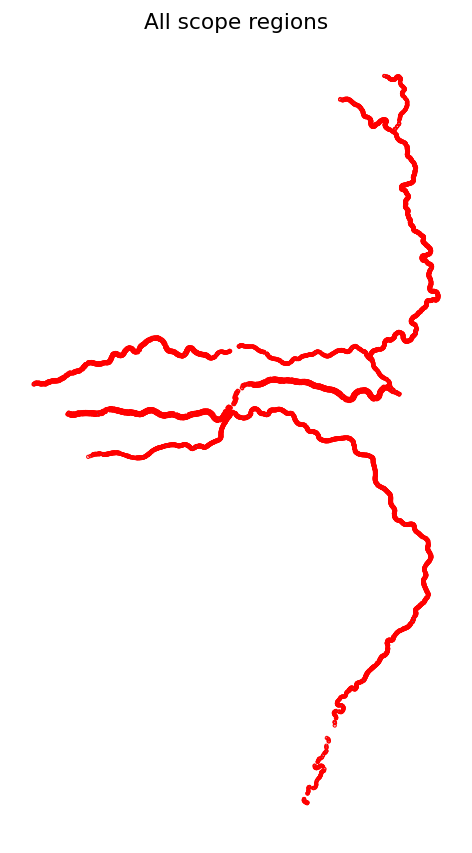

In [87]:
# Minimal map: all scope regions (first-principles test)
print(f"scope: {len(scope)} regions, CRS={scope.crs}, bounds={scope.total_bounds}")
fig, ax = plt.subplots(figsize=(10, 8))
scope.plot(ax=ax, color="steelblue", edgecolor="red", linewidth=2)
ax.set_title("All scope regions")
ax.set_axis_off()
plt.show()

In [88]:
def feature_overview(scope_gdf, features_df, col, title,
                     cmap="Set2", figsize=(16, 5),
                     order=None, palette=None, layout="side_by_side"):
    """
    Two-panel figure:
      Left  — geographic map of scope regions coloured by `col`
      Right — mean v_test ± SE per category, n labelled

    layout: "side_by_side" (default) or "stacked" — stacked puts map above bar chart.
    """
    # Merge feature column into scope for plotting
    plot_gdf = scope_gdf.join(features_df[[col, "v_test"]].dropna(subset=[col]))

    cats = order or sorted(plot_gdf[col].dropna().unique())
    if palette is None:
        colors = dict(zip(cats, plt.cm.get_cmap(cmap, len(cats)).colors))
    else:
        colors = dict(zip(cats, palette))

    if layout == "stacked":
        # Map full-width above bar chart — avoids subplot aspect-ratio issues
        fig, axes = plt.subplots(2, 1, figsize=(figsize[0], 8),
                                 gridspec_kw={"height_ratios": [1.5, 1], "hspace": 0.35})
        ax_map, ax_bar = axes[0], axes[1]
    else:
        fig = plt.figure(figsize=figsize, constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[2, 1], wspace=0.25)
        ax_map = fig.add_subplot(gs[0])
        ax_bar = fig.add_subplot(gs[1])

    # ── Map ─────────────────────────────────────────────────────────────────
    xmin, ymin, xmax, ymax = scope_gdf.total_bounds
    ax_map.set_xlim(xmin, xmax)
    ax_map.set_ylim(ymin, ymax)
    ax_map.set_aspect(1)
    # Edge color matches fill so thick edges don't create a black mesh
    scope_gdf.plot(ax=ax_map, color="#e8e8e8", linewidth=2, edgecolor="#e8e8e8")
    for cat in cats:
        sub = plot_gdf[plot_gdf[col] == cat]
        if len(sub):
            sub.plot(ax=ax_map, color=colors[cat], linewidth=2, edgecolor=colors[cat], label=cat)
    ax_map.set_axis_off()
    ax_map.set_title(f"Geographic distribution — {title}", fontsize=10)
    handles = [mpatches.Patch(color=colors[c], label=c) for c in cats]
    handles += [mpatches.Patch(color="#e8e8e8", label="no data")]
    ax_map.legend(handles=handles, loc="lower left", fontsize=7,
                  framealpha=0.85, ncol=2)

    # ── Bar chart ────────────────────────────────────────────────────────────
    df_v = plot_gdf.dropna(subset=["v_test", col])
    stats_df = df_v.groupby(col)["v_test"].agg(
        mean="mean", sem=lambda x: x.sem(), n="count"
    ).loc[cats]

    x = np.arange(len(cats))
    ax_bar.bar(x, stats_df["mean"],
               yerr=stats_df["sem"], capsize=4,
               color=[colors[c] for c in cats],
               edgecolor="white", linewidth=0.5)
    ax_bar.axhline(0, color="grey", lw=0.8, ls=":")
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(cats, rotation=30, ha="right", fontsize=8)
    ax_bar.set_ylabel("Mean v_test  (m / yr)")
    ax_bar.set_title(f"Mean erosion rate by {title}", fontsize=10)
    for xi, cat in enumerate(cats):
        row = stats_df.loc[cat]
        ax_bar.text(xi, row["mean"] + row["sem"] + 0.05,
                    f"n={int(row['n'])}", ha="center", fontsize=7, color="#333")

    # KW test
    groups = [df_v.loc[df_v[col] == c, "v_test"].values for c in cats]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        h, p = stats.kruskal(*groups)
        ax_bar.set_xlabel(f"Kruskal-Wallis  H={h:.1f}, p={p:.2e}", fontsize=8)

    plt.suptitle(title, fontweight="bold", fontsize=12)
    plt.show()

print("Helper function defined.")


Helper function defined.


## 1 — Target: v_test distribution

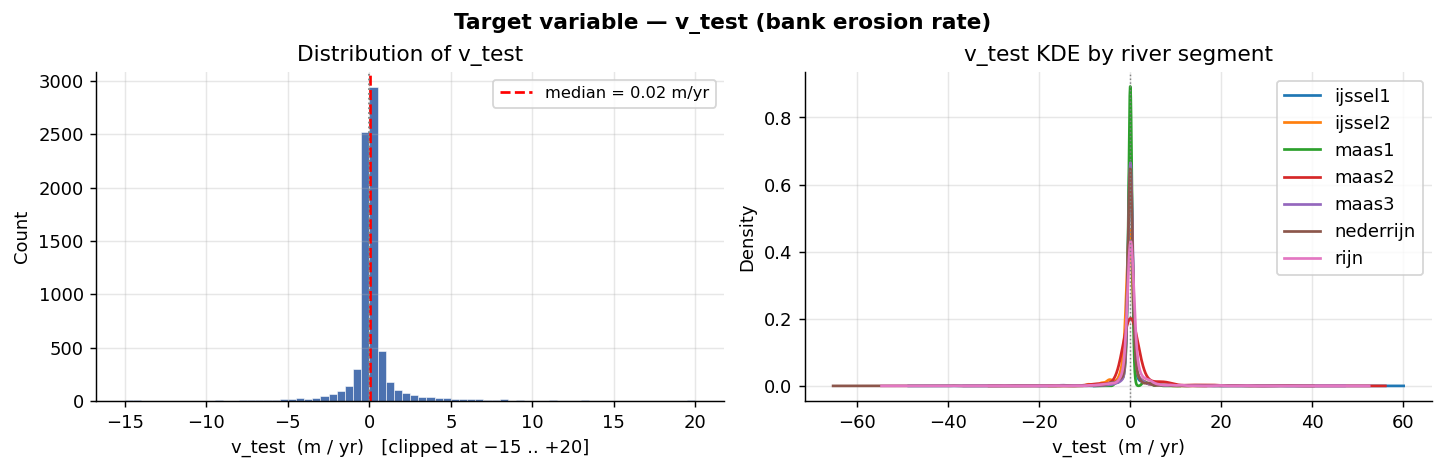

count    7444.000
mean        0.150
std         2.187
min       -38.896
25%        -0.111
50%         0.021
75%         0.223
max        34.273
Name: v_test, dtype: float64


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)

ax = axes[0]
ax.hist(features["v_test"].clip(-15, 20), bins=70,
        color="#4c72b0", edgecolor="white", lw=0.3)
ax.axvline(features["v_test"].median(), color="red", lw=1.5, ls="--",
           label=f"median = {features['v_test'].median():.2f} m/yr")
ax.axvline(0, color="grey", lw=1, ls=":")
ax.set_xlabel("v_test  (m / yr)   [clipped at −15 .. +20]")
ax.set_ylabel("Count")
ax.set_title("Distribution of v_test")
ax.legend(fontsize=9)

ax = axes[1]
features.groupby("river")["v_test"].plot(kind="kde", ax=ax, legend=True)
ax.set_xlabel("v_test  (m / yr)")
ax.set_title("v_test KDE by river segment")
ax.axvline(0, color="grey", lw=0.8, ls=":")

plt.suptitle("Target variable — v_test (bank erosion rate)", fontweight="bold")
plt.show()
print(features["v_test"].describe().round(3))


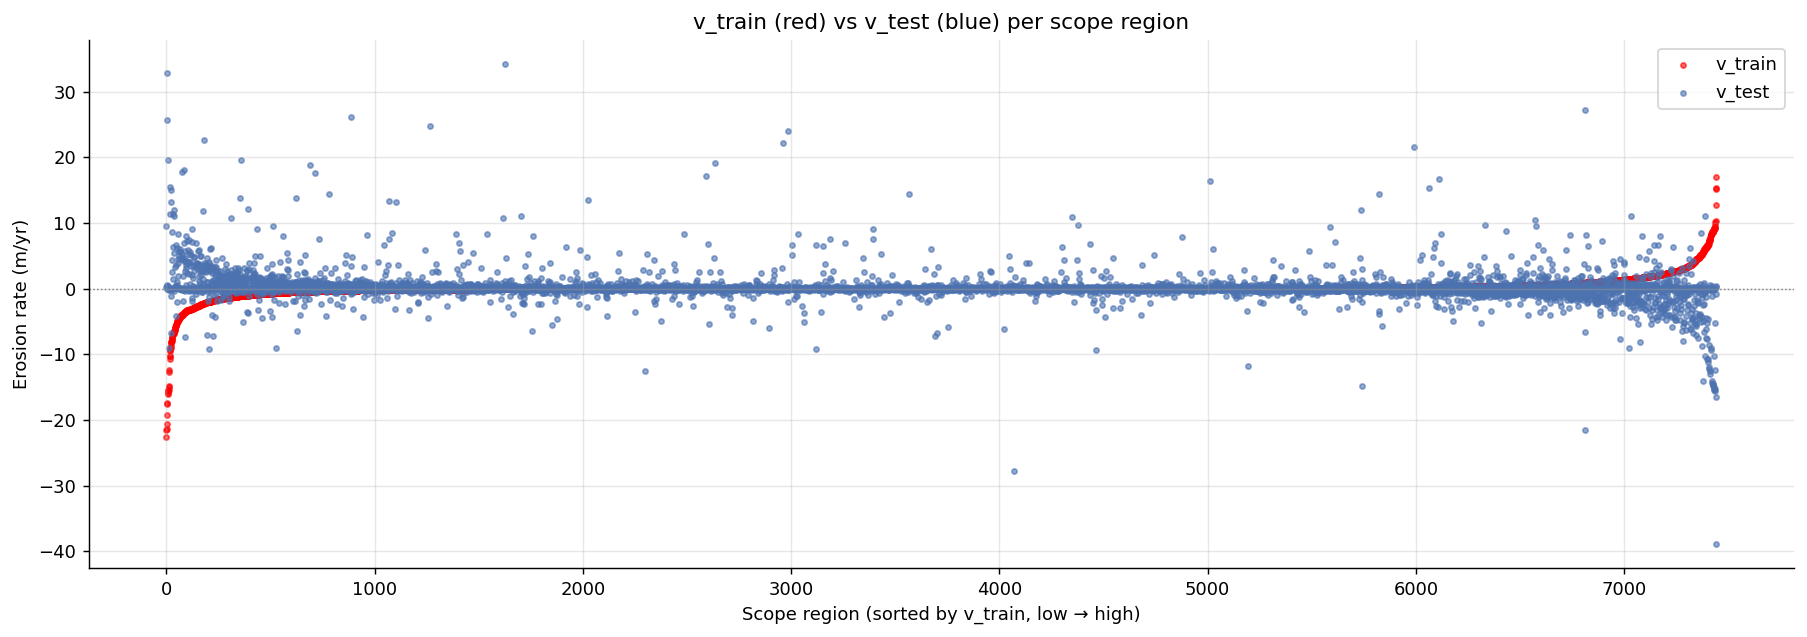

In [90]:
# v_train vs v_test per scope region — sorted by v_train (low to high)
df = features[["v_train", "v_test"]].dropna()
df = df.sort_values("v_train").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(df))
ax.scatter(x, df["v_train"], c="red", s=8, alpha=0.6, label="v_train")
ax.scatter(x, df["v_test"], c="#4c72b0", s=8, alpha=0.6, label="v_test")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("Scope region (sorted by v_train, low → high)")
ax.set_ylabel("Erosion rate (m/yr)")
ax.set_title("v_train (red) vs v_test (blue) per scope region")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 1b — Erosion volume (m³/yr)

**Check:** Is erosion volume always positive?  
**Influence:** How does erosion volume correlate with `v_test`?

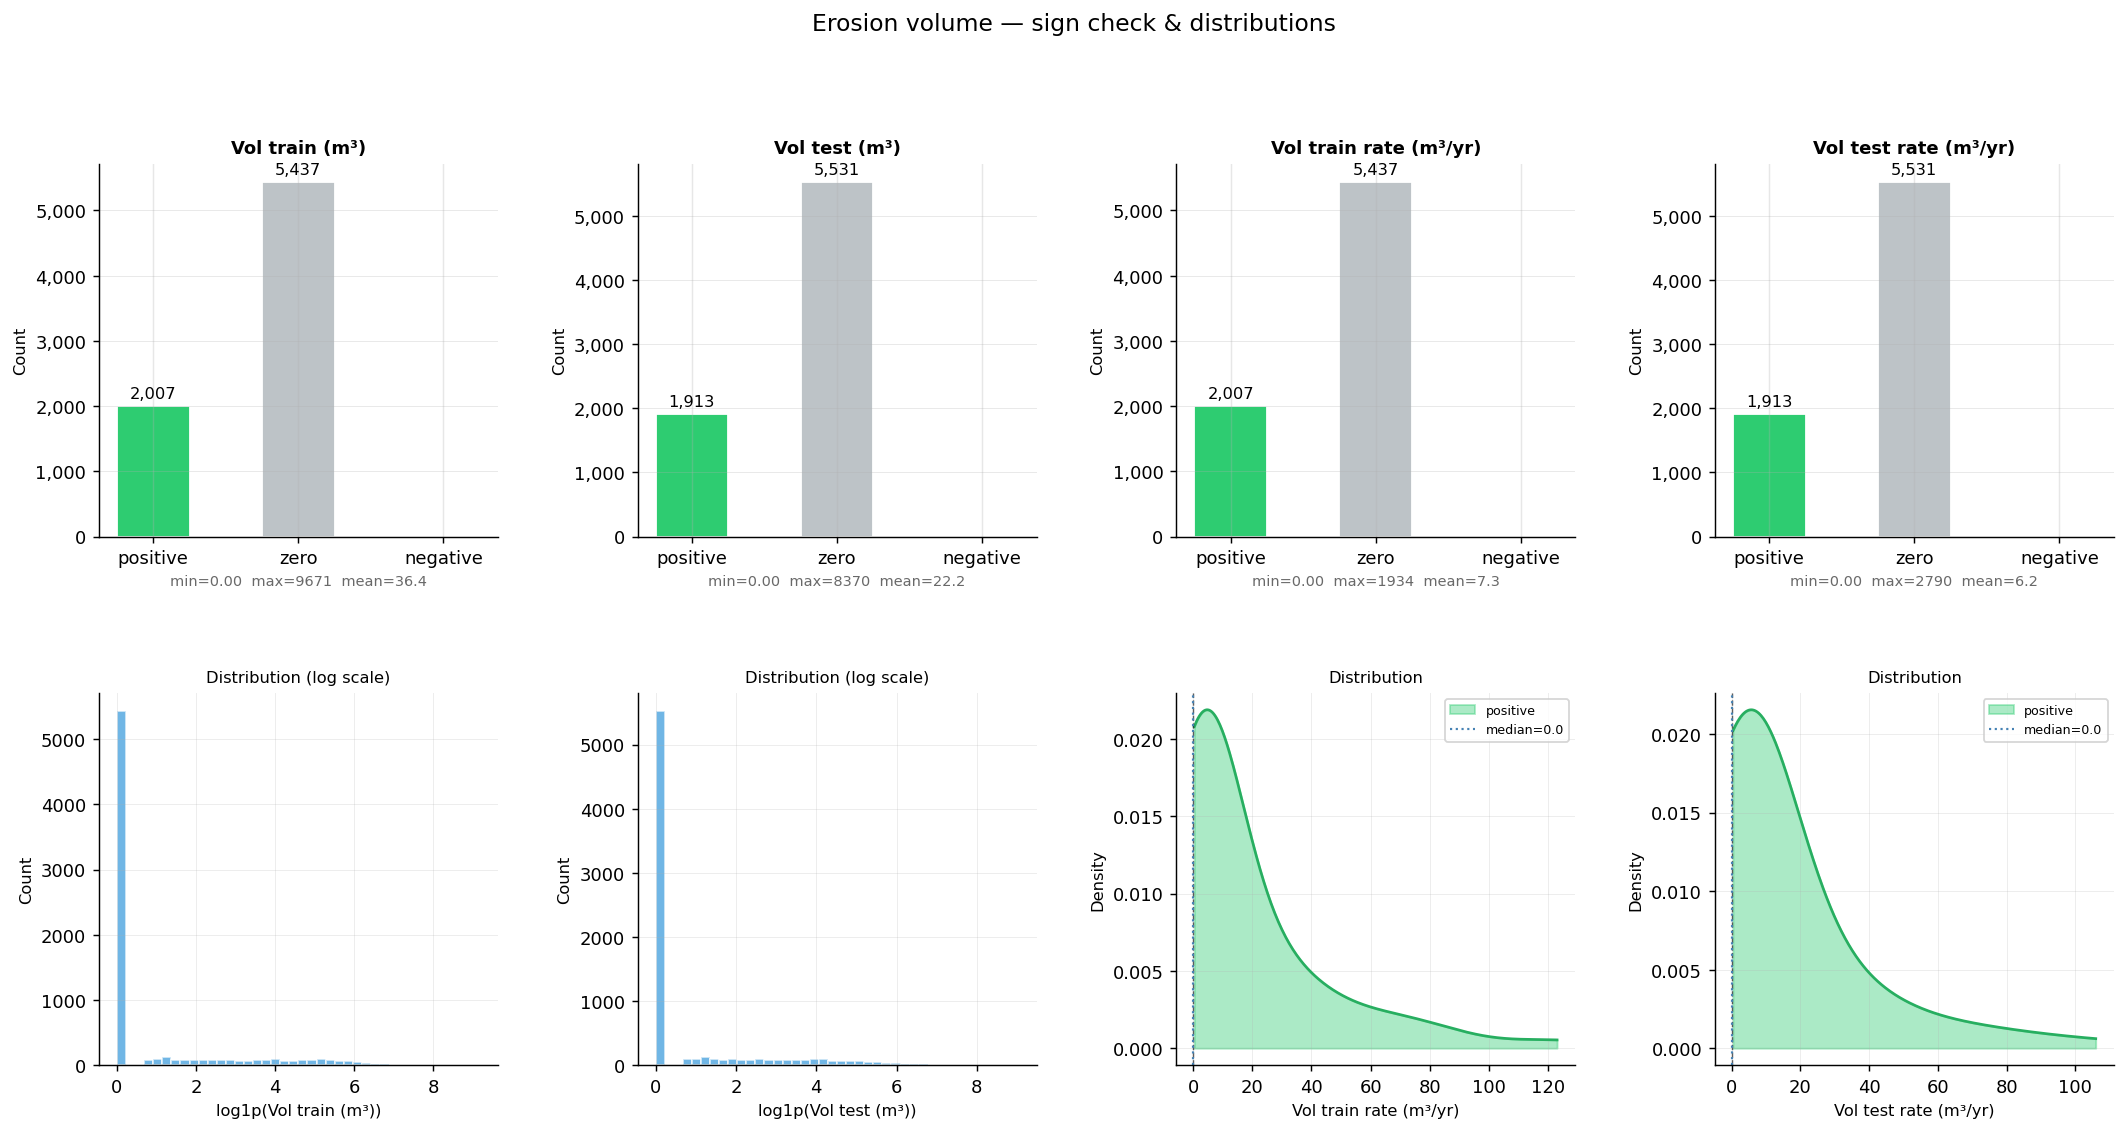

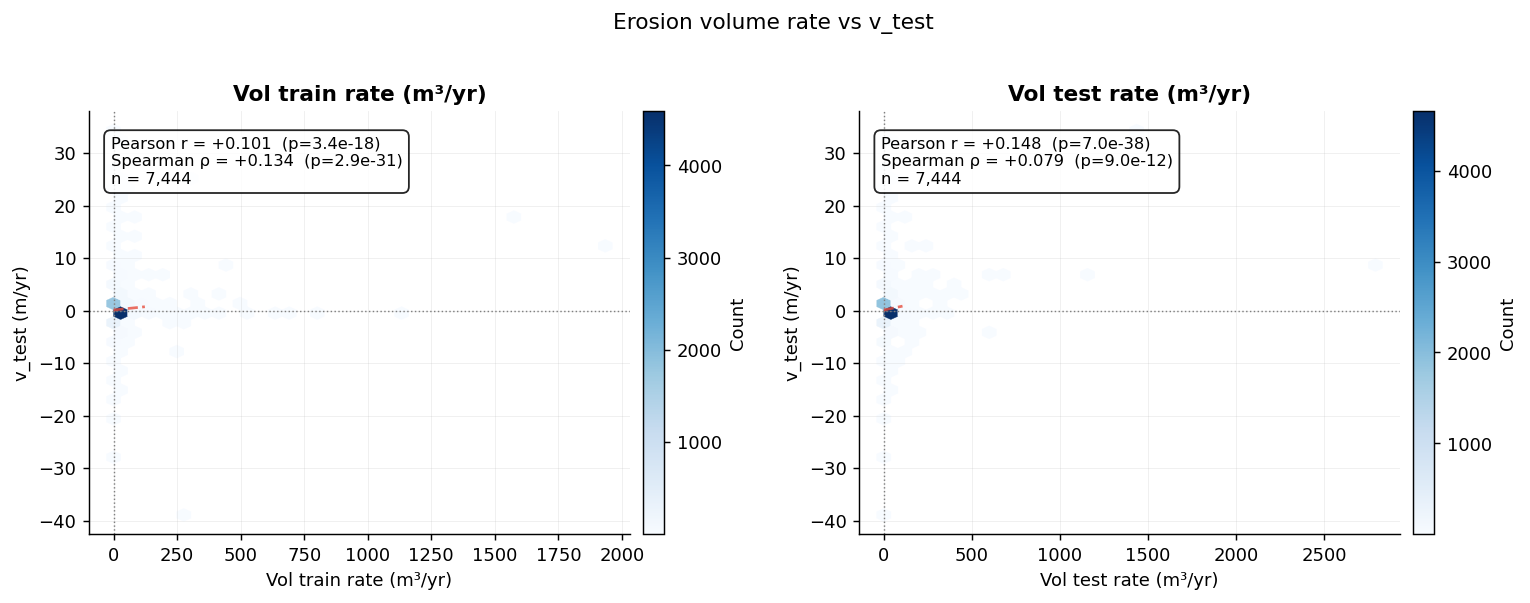

In [126]:
# ══════════════════════════════════════════════════════════════════════════════
# Erosion volume — diagnostics & correlation with v_test
# ══════════════════════════════════════════════════════════════════════════════

vol_cols = [c for c in ["erosion_vol_train_m3", "erosion_vol_test_m3",
                         "erosion_vol_train_rate", "erosion_vol_test_rate"]
            if c in features.columns]

if not vol_cols:
    print("No erosion volume columns found in features.")
else:
    RATE_COLS = ["erosion_vol_train_rate", "erosion_vol_test_rate"]
    rate_cols = [c for c in RATE_COLS if c in features.columns]

    # ── Panel layout ─────────────────────────────────────────────────────────
    # Row 1: sign/value summary bars  (one panel per column)
    # Row 2: distributions (KDE) + hexbin scatter (rate vs v_test)
    n_cols  = len(vol_cols)
    fig     = plt.figure(figsize=(5 * n_cols, 9))
    gs      = fig.add_gridspec(2, n_cols, hspace=0.42, wspace=0.35)

    PALETTE = {"positive": "#2ecc71", "zero": "#bdc3c7", "negative": "#e74c3c"}
    LABELS  = {
        "erosion_vol_train_m3":   "Vol train (m³)",
        "erosion_vol_test_m3":    "Vol test (m³)",
        "erosion_vol_train_rate": "Vol train rate (m³/yr)",
        "erosion_vol_test_rate":  "Vol test rate (m³/yr)",
    }

    # ── Row 1: sign bar + stats annotation ───────────────────────────────────
    for i, col in enumerate(vol_cols):
        ax  = fig.add_subplot(gs[0, i])
        vals = features[col].dropna()
        counts = {
            "positive": (vals > 0).sum(),
            "zero":     (vals == 0).sum(),
            "negative": (vals < 0).sum(),
        }
        bars = ax.bar(counts.keys(), counts.values(),
                      color=[PALETTE[k] for k in counts],
                      edgecolor="white", width=0.5)
        for bar, (k, v) in zip(bars, counts.items()):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + len(vals) * 0.01,
                        f"{v:,}", ha="center", va="bottom", fontsize=9)

        # Warn or summarise
        if counts["negative"] > 0:
            ax.set_facecolor("#fff5f5")
            subtitle = f"⚠ {counts['negative']} negative values  min={vals.min():.3f}"
            color = "#c0392b"
        else:
            subtitle = f"min={vals.min():.2f}  max={vals.max():.0f}  mean={vals.mean():.1f}"
            color = "dimgray"

        ax.set_title(LABELS.get(col, col), fontweight="bold", fontsize=10)
        ax.set_xlabel(subtitle, fontsize=8, color=color)
        ax.set_ylabel("Count", fontsize=9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
        ax.grid(axis="y", alpha=0.3, lw=0.5)
        ax.spines[["top", "right"]].set_visible(False)

    # ── Row 2: KDE for rate columns + hexbin scatter ──────────────────────────
    # If we have both rate cols, plot KDEs in first two panels and scatter in third/fourth
    # If only one rate col, KDE left, scatter right
    for i, col in enumerate(vol_cols):
        ax = fig.add_subplot(gs[1, i])
        vals = features[col].dropna()

        if col in rate_cols:
            # KDE with rug for sign
            from scipy.stats import gaussian_kde
            pos_vals = vals[vals > 0]
            neg_vals = vals[vals < 0]
            x_range  = np.linspace(vals.quantile(0.01), vals.quantile(0.99), 300)
            if len(pos_vals) > 5:
                kde_pos = gaussian_kde(pos_vals, bw_method=0.15)
                ax.fill_between(x_range, kde_pos(x_range),
                                where=(x_range > 0), alpha=0.4, color="#2ecc71", label="positive")
                ax.plot(x_range[x_range > 0], kde_pos(x_range[x_range > 0]),
                        color="#27ae60", lw=1.5)
            if len(neg_vals) > 5:
                kde_neg = gaussian_kde(neg_vals, bw_method=0.15)
                ax.fill_between(x_range, kde_neg(x_range),
                                where=(x_range < 0), alpha=0.4, color="#e74c3c", label="negative")
                ax.plot(x_range[x_range < 0], kde_neg(x_range[x_range < 0]),
                        color="#c0392b", lw=1.5)
            ax.axvline(0, color="black", ls="--", lw=0.8, alpha=0.6)
            ax.axvline(vals.median(), color="steelblue", ls=":", lw=1.2,
                       label=f"median={vals.median():.1f}")
            ax.set_xlabel(LABELS.get(col, col), fontsize=9)
            ax.set_ylabel("Density", fontsize=9)
            ax.set_title("Distribution", fontsize=9)
            ax.legend(fontsize=7)
            ax.spines[["top", "right"]].set_visible(False)
            ax.grid(alpha=0.25, lw=0.5)

        else:
            # For m³ columns: simple log-scale histogram
            ax.hist(np.log1p(vals.clip(lower=0)), bins=40,
                    color="#3498db", alpha=0.7, edgecolor="white")
            ax.set_xlabel(f"log1p({LABELS.get(col, col)})", fontsize=9)
            ax.set_ylabel("Count", fontsize=9)
            ax.set_title("Distribution (log scale)", fontsize=9)
            ax.spines[["top", "right"]].set_visible(False)
            ax.grid(alpha=0.25, lw=0.5)

    plt.suptitle("Erosion volume — sign check & distributions", fontsize=13, y=1.01)
    plt.show()

    # ── Scatter: both rate cols vs v_test, side by side ───────────────────────
    if rate_cols:
        fig2, axes = plt.subplots(1, len(rate_cols), figsize=(6 * len(rate_cols), 4.5))
        if len(rate_cols) == 1:
            axes = [axes]

        for ax, col in zip(axes, rate_cols):
            df_v = features.dropna(subset=[col, "v_test"])
            r,   p_r   = stats.pearsonr(df_v[col], df_v["v_test"])
            rho, p_rho = stats.spearmanr(df_v[col], df_v["v_test"])

            hb = ax.hexbin(df_v[col], df_v["v_test"],
                           gridsize=35, cmap="Blues", mincnt=1, linewidths=0.2)
            fig2.colorbar(hb, ax=ax, label="Count", pad=0.02)
            ax.axhline(0, color="grey", ls=":", lw=0.8)
            ax.axvline(0, color="grey", ls=":", lw=0.8)

            # Regression line
            m, b = np.polyfit(df_v[col], df_v["v_test"], 1)
            x_line = np.linspace(df_v[col].quantile(0.01), df_v[col].quantile(0.99), 100)
            ax.plot(x_line, m * x_line + b, color="#e74c3c", lw=1.5, ls="--", alpha=0.8)

            ax.set_xlabel(LABELS.get(col, col), fontsize=10)
            ax.set_ylabel("v_test (m/yr)", fontsize=10)
            ax.set_title(LABELS.get(col, col), fontweight="bold")
            ax.annotate(
                f"Pearson r = {r:+.3f}  (p={p_r:.1e})\nSpearman ρ = {rho:+.3f}  (p={p_rho:.1e})\nn = {len(df_v):,}",
                xy=(0.04, 0.94), xycoords="axes fraction",
                fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85),
            )
            ax.spines[["top", "right"]].set_visible(False)
            ax.grid(alpha=0.2, lw=0.5)

        plt.suptitle("Erosion volume rate vs v_test", fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()

## 2 — Feature: v_train (historical erosion rate)

**Hypothesis:** Past erosion predicts future erosion. Note that strong mean-reversion is expected (banks that eroded a lot become flatter/further → less future erosion).

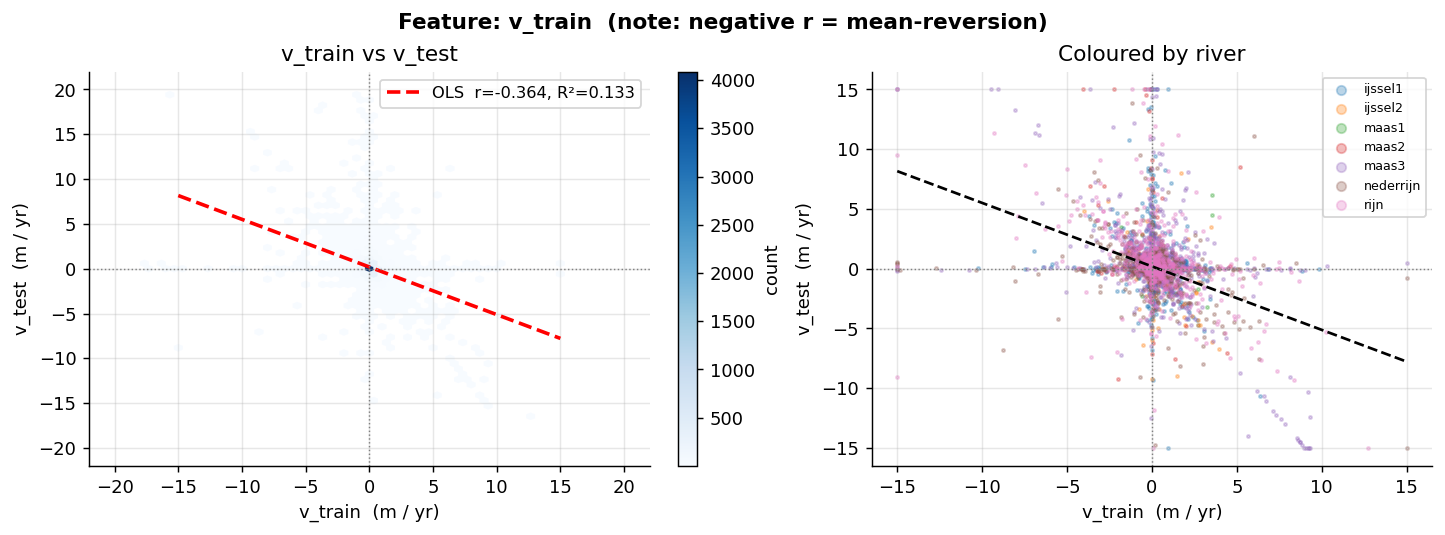

Pearson r = -0.3644   R² = 0.1328   p = 1.38e-232
Interpretation: r<0 means fast eroding banks slow down (mean-reversion).


In [92]:
df = features.dropna(subset=["v_train","v_test"])
slope, intercept, r, p, _ = stats.linregress(df["v_train"], df["v_test"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax = axes[0]
hb = ax.hexbin(df["v_train"], df["v_test"], gridsize=60, cmap="Blues",
               mincnt=1, linewidths=0.2, extent=(-20, 20, -20, 20))
x_ = np.linspace(-15, 15, 100)
ax.plot(x_, slope * x_ + intercept, "r--", lw=2,
        label=f"OLS  r={r:.3f}, R²={r**2:.3f}")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.axvline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("v_train  (m / yr)")
ax.set_ylabel("v_test  (m / yr)")
ax.set_title("v_train vs v_test")
ax.legend(fontsize=9)
plt.colorbar(hb, ax=ax, label="count")

ax = axes[1]
# Scatter in both quadrants with annotations
for river, grp in df.groupby("river"):
    ax.scatter(grp["v_train"].clip(-15,15), grp["v_test"].clip(-15,15),
               s=3, alpha=0.3, label=river)
ax.plot(x_, slope * x_ + intercept, "k--", lw=1.5)
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.axvline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("v_train  (m / yr)")
ax.set_ylabel("v_test  (m / yr)")
ax.set_title("Coloured by river")
ax.legend(fontsize=7, markerscale=3)

plt.suptitle("Feature: v_train  (note: negative r = mean-reversion)", fontweight="bold")
plt.show()
print(f"Pearson r = {r:.4f}   R² = {r**2:.4f}   p = {p:.2e}")
print(f"Interpretation: r<0 means fast eroding banks slow down (mean-reversion).")


## 3 — Feature: dist_t2 (absolute bank position at t2)

**Hypothesis:** Banks further from the centreline are exposed to weaker currents → erode slower.

**Per-cluster analysis:** 150 m from centreline at Rijn may differ from ijssel1 (different river widths, flow). We test dist_t2 vs v_test separately per cluster.

dist_t2 vs v_test — per cluster:
  cluster    n  Pearson_r    Pearson_p  Spearman_rho   Spearman_p
  ijssel1 1810  -0.064843 5.785405e-03      0.010390 6.586837e-01
  ijssel2  287  -0.353448 7.198099e-10     -0.361636 2.705698e-10
    maas1  127   0.011601 8.970049e-01     -0.152802 8.633489e-02
    maas2  178  -0.116617 1.210931e-01     -0.056959 4.501399e-01
    maas3 2681  -0.224852 4.483721e-32     -0.075201 9.719677e-05
nederrijn 1198  -0.136914 1.971239e-06     -0.073243 1.121773e-02
     rijn 1163  -0.017926 5.413776e-01      0.054799 6.173598e-02



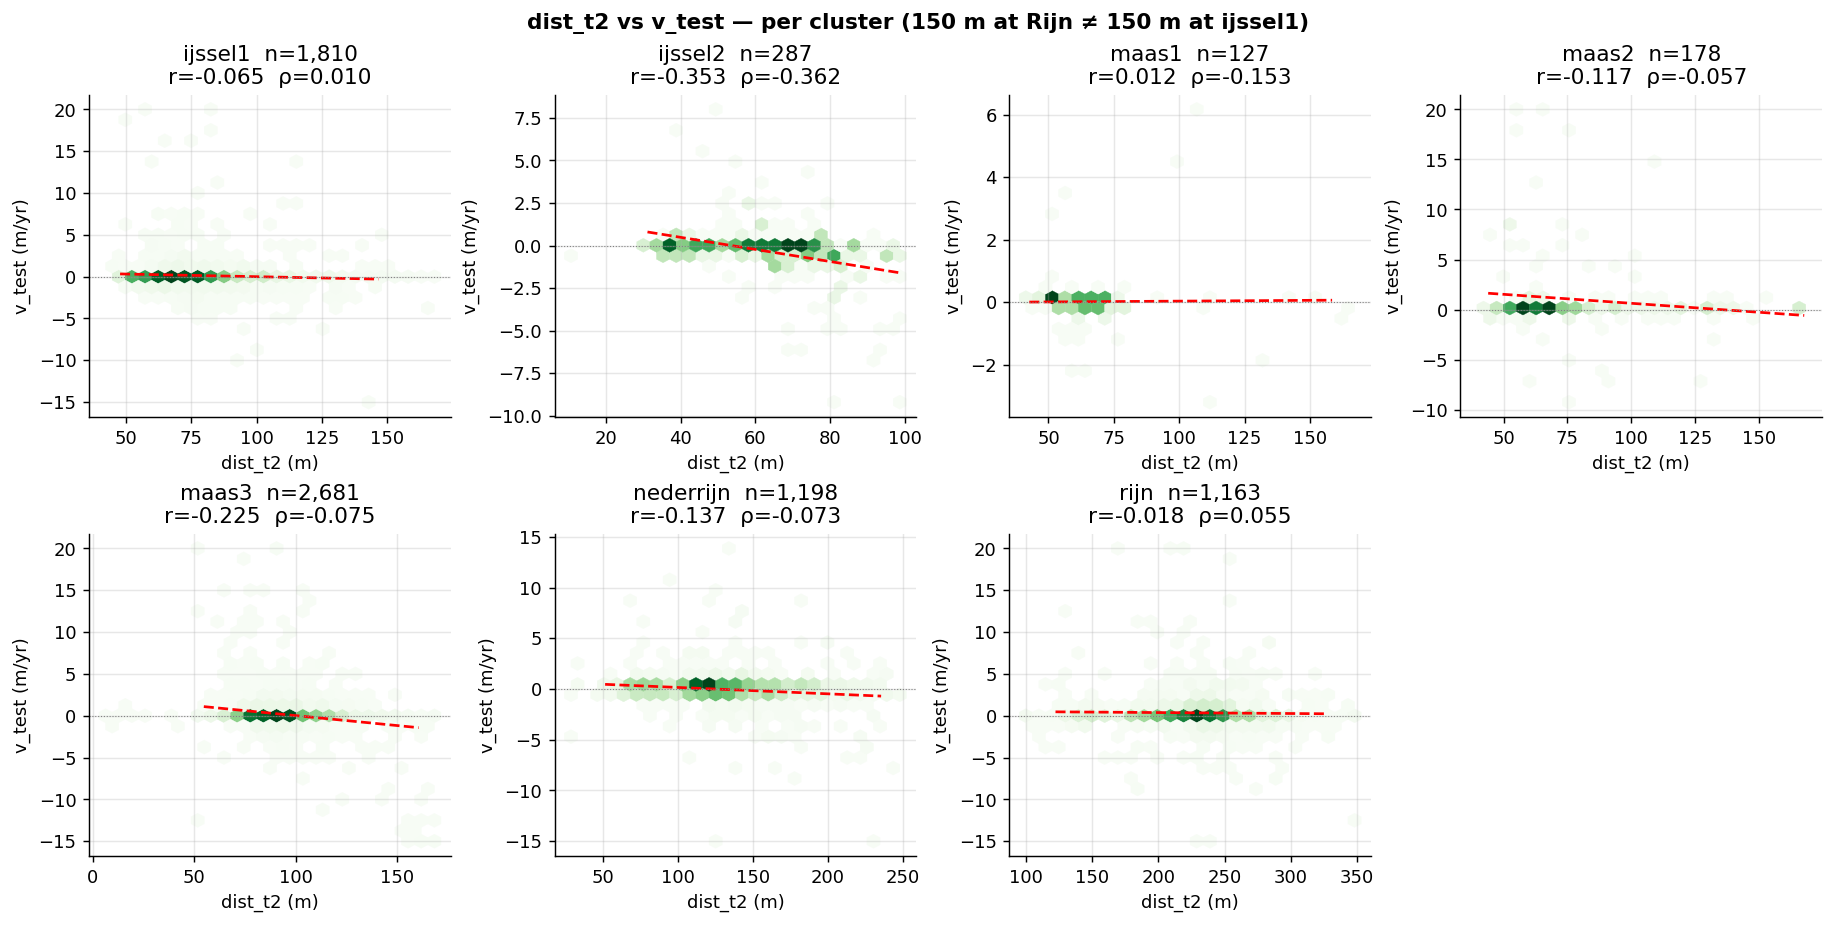

In [93]:
df = features.dropna(subset=["dist_t2", "v_test", "cluster"])

# Per-cluster summary
clusters = sorted(df["cluster"].unique())
results = []
for cl in clusters:
    sub = df[df["cluster"] == cl]
    if len(sub) < 10:
        continue
    r_lin, p_lin = stats.pearsonr(sub["dist_t2"], sub["v_test"])
    rho, p_sp = stats.spearmanr(sub["dist_t2"], sub["v_test"])
    results.append({"cluster": cl, "n": len(sub), "Pearson_r": r_lin, "Pearson_p": p_lin,
                    "Spearman_rho": rho, "Spearman_p": p_sp})

res_df = pd.DataFrame(results)
print("dist_t2 vs v_test — per cluster:")
print(res_df.to_string(index=False))
print()

# Grid of subplots: one per cluster
n_cl = len(clusters)
n_cols = 4
n_rows = (n_cl + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), constrained_layout=True)
axes = np.atleast_2d(axes)

for idx, cl in enumerate(clusters):
    row, col = idx // n_cols, idx % n_cols
    ax = axes[row, col]
    sub = df[df["cluster"] == cl]
    if len(sub) < 10:
        ax.text(0.5, 0.5, f"{cl}\nn={len(sub)}", ha="center", va="center", fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_axis_off()
        continue
    hb = ax.hexbin(sub["dist_t2"], sub["v_test"].clip(-15, 20), gridsize=25,
                   cmap="Greens", mincnt=1, linewidths=0.2)
    slope, intercept, *_ = stats.linregress(sub["dist_t2"], sub["v_test"])
    x_ = np.linspace(sub["dist_t2"].quantile(0.01), sub["dist_t2"].quantile(0.99), 100)
    ax.plot(x_, slope * x_ + intercept, "r--", lw=1.5)
    r_lin, _ = stats.pearsonr(sub["dist_t2"], sub["v_test"])
    rho, _ = stats.spearmanr(sub["dist_t2"], sub["v_test"])
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_xlabel("dist_t2 (m)")
    ax.set_ylabel("v_test (m/yr)")
    ax.set_title(f"{cl}  n={len(sub):,}\nr={r_lin:.3f}  ρ={rho:.3f}")

# Hide unused axes
for idx in range(len(clusters), n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    axes[row, col].set_axis_off()

plt.suptitle("dist_t2 vs v_test — per cluster (150 m at Rijn ≠ 150 m at ijssel1)", fontweight="bold")
plt.show()


## 4 — Feature: is_nvo (nature-friendly bank)

**Hypothesis:** NVO banks have gentle slopes and soft vegetation → erode faster.

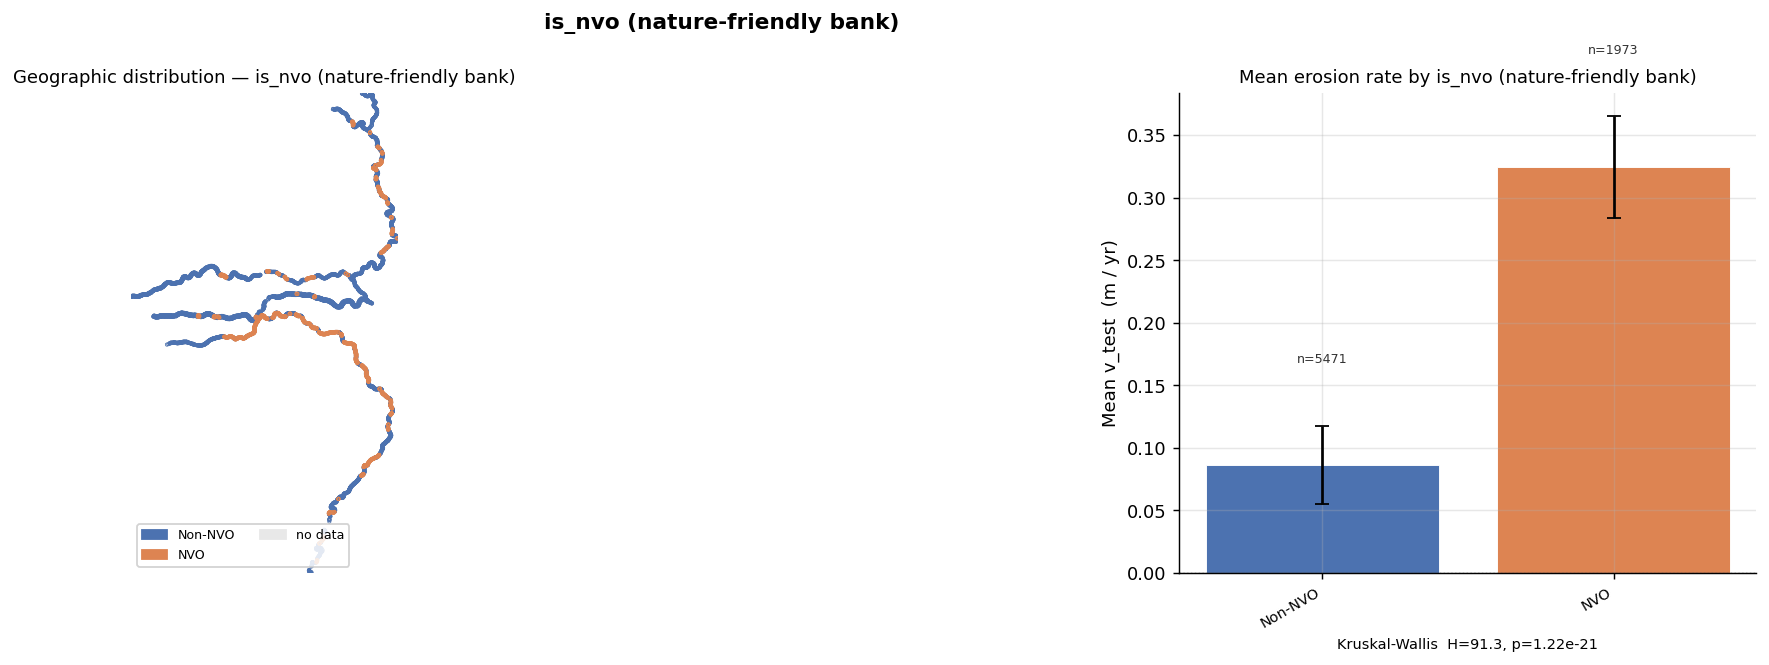

Non-NVO  mean=0.087  median=0.000  n=5,471
NVO      mean=0.324  median=0.056  n=1,973
Mann-Whitney p=1.2226e-21   Cohen's d=0.115


In [94]:
feat_nvo = features.copy()
feat_nvo["is_nvo"] = feat_nvo["is_nvo"].map({False: "Non-NVO", True: "NVO"})
feature_overview(
    scope, feat_nvo,
    col="is_nvo",
    title="is_nvo (nature-friendly bank)",
    order=["Non-NVO", "NVO"],
    palette=["#4c72b0","#dd8452"],
)
nvo     = features.loc[features["is_nvo"],  "v_test"].dropna()
non_nvo = features.loc[~features["is_nvo"], "v_test"].dropna()
u, p = stats.mannwhitneyu(nvo, non_nvo, alternative="two-sided")
d = (nvo.mean()-non_nvo.mean()) / np.sqrt((nvo.std()**2+non_nvo.std()**2)/2)
print(f"Non-NVO  mean={non_nvo.mean():.3f}  median={non_nvo.median():.3f}  n={len(non_nvo):,}")
print(f"NVO      mean={nvo.mean():.3f}  median={nvo.median():.3f}  n={len(nvo):,}")
print(f"Mann-Whitney p={p:.4e}   Cohen's d={d:.3f}")


## 5 — Feature: river segment

**Hypothesis:** Different rivers have different flow regimes, morphology, and bank protection → systematic differences in erosion rate.

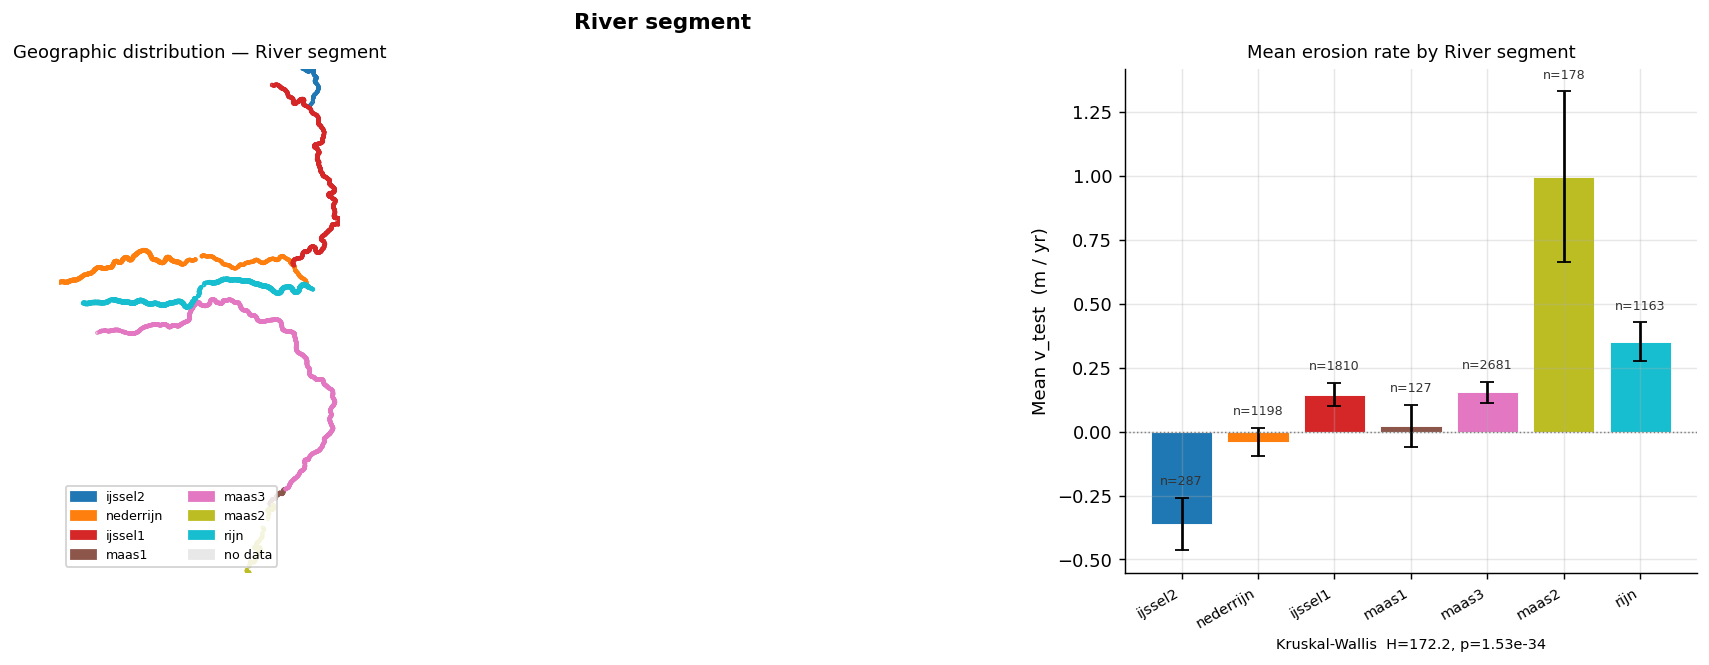

In [95]:
river_order = (features.dropna(subset=["v_test"])
               .groupby("river")["v_test"].median()
               .sort_values().index.tolist())

feature_overview(
    scope, features,
    col="river",
    title="River segment",
    order=river_order,
    cmap="tab10",
)


## 6 — Feature: vegetation class (vegetatielegger)

**Source:** `02_processed/wfs_context/vegetatielegger.gpkg` — already pre-joined to scope regions.

**Hypothesis:** Soft/reed vegetation is easily disturbed; hard surfaces and forest are more resistant.

In [96]:
# Load vegetation klassen — already has scope_region_id
veg = gpd.read_file(str(VEG_GPKG), layer="rws_vegetatielegger:vegetatieklassen")
print(f"Vegetation polygons: {len(veg):,}  |  scope regions covered: {veg['scope_region_id'].nunique():,} / {len(features):,}")
print("\nVegetation class distribution:")
print(veg["vlklasse"].value_counts().to_string())

# Dominant class per scope region by area
veg["area"] = veg.geometry.area
dom_veg = (veg.sort_values("area", ascending=False)
           .groupby("scope_region_id")["vlklasse"]
           .first()
           .rename("vegetation_class"))

features["vegetation_class"] = features.index.map(dom_veg)
missing = features["vegetation_class"].isna().sum()
print(f"\nAssigned: {features['vegetation_class'].notna().sum():,} / {len(features):,}  "
      f"({features['vegetation_class'].notna().mean():.1%} coverage)  |  Missing: {missing:,}")


Vegetation polygons: 28,869  |  scope regions covered: 8,541 / 7,444

Vegetation class distribution:
vlklasse
Struweel             6679
Verhard oppervlak    6281
Riet en Ruigte       6037
Bos                  4849
Gras en Akker        3804
Water                 959
90/10                 139
70/30                  78
50/50                  43

Assigned: 5,420 / 7,444  (72.8% coverage)  |  Missing: 2,024


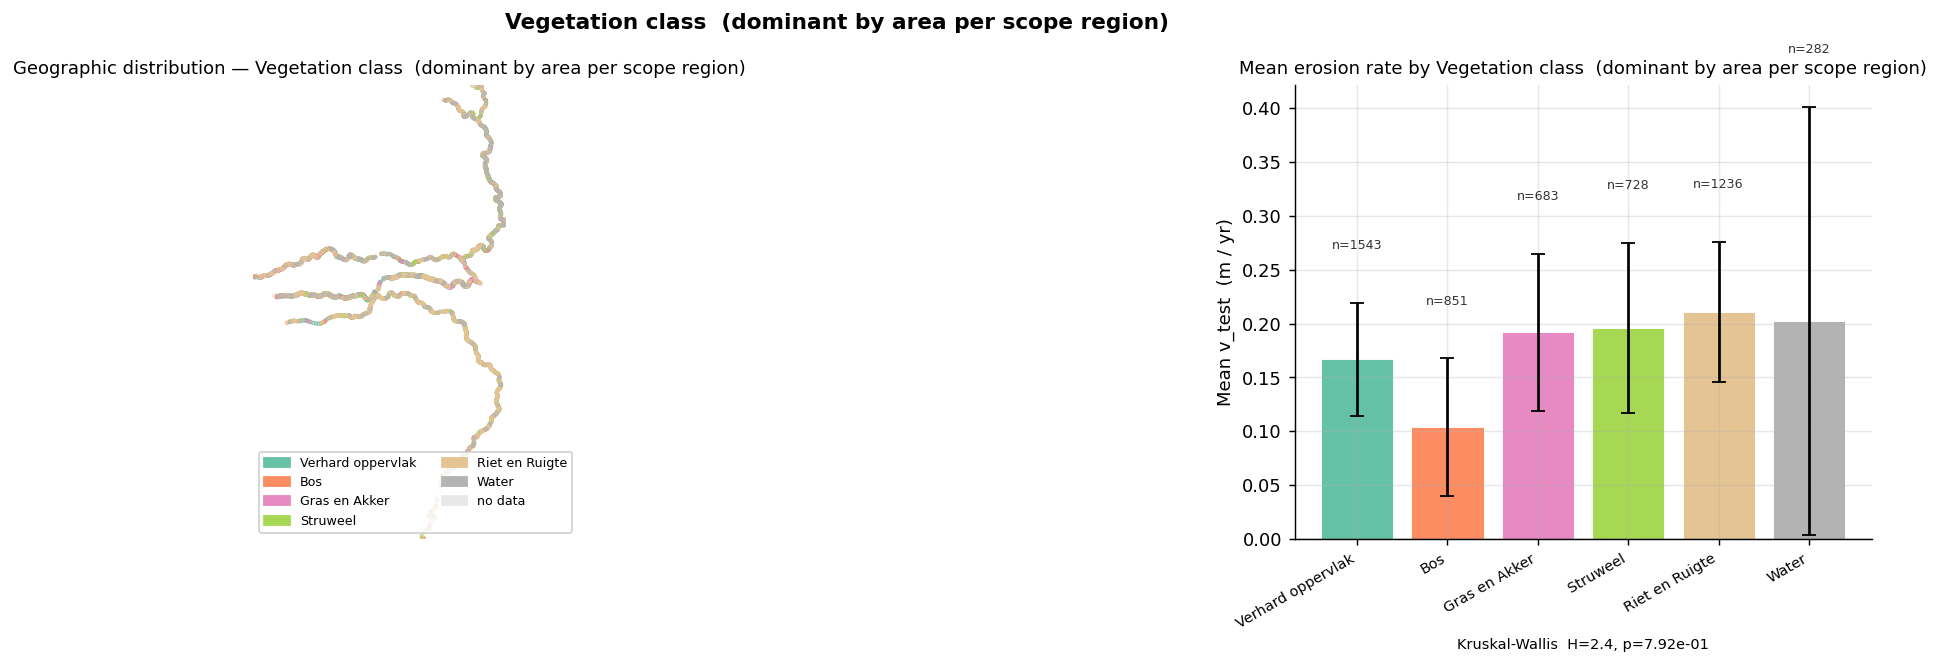

In [97]:
veg_order = ["Verhard oppervlak","Bos","Gras en Akker","Struweel",
             "Riet en Ruigte","Water"]
veg_order = [v for v in veg_order if v in features["vegetation_class"].values]

feature_overview(
    scope, features,
    col="vegetation_class",
    title="Vegetation class  (dominant by area per scope region)",
    order=veg_order,
    cmap="Set2",
)


## 7 — Feature: land use (BRP Gewas)

**Source:** `02_processed/wfs_context/land_use.gpkg` — pre-joined to scope regions.

**Coverage is lower (~38%).** Note: this dataset may not cover the VVR zone itself.

Land use polygons: 10,397  |  scope regions: 4,616 / 7,444
Assigned: 2,871 / 7,444  (38.6% coverage)
category
Grasland             5247
Landschapselement    3528
Bouwland             1176
Natuurterrein         423
Overige                14
Braakland               9


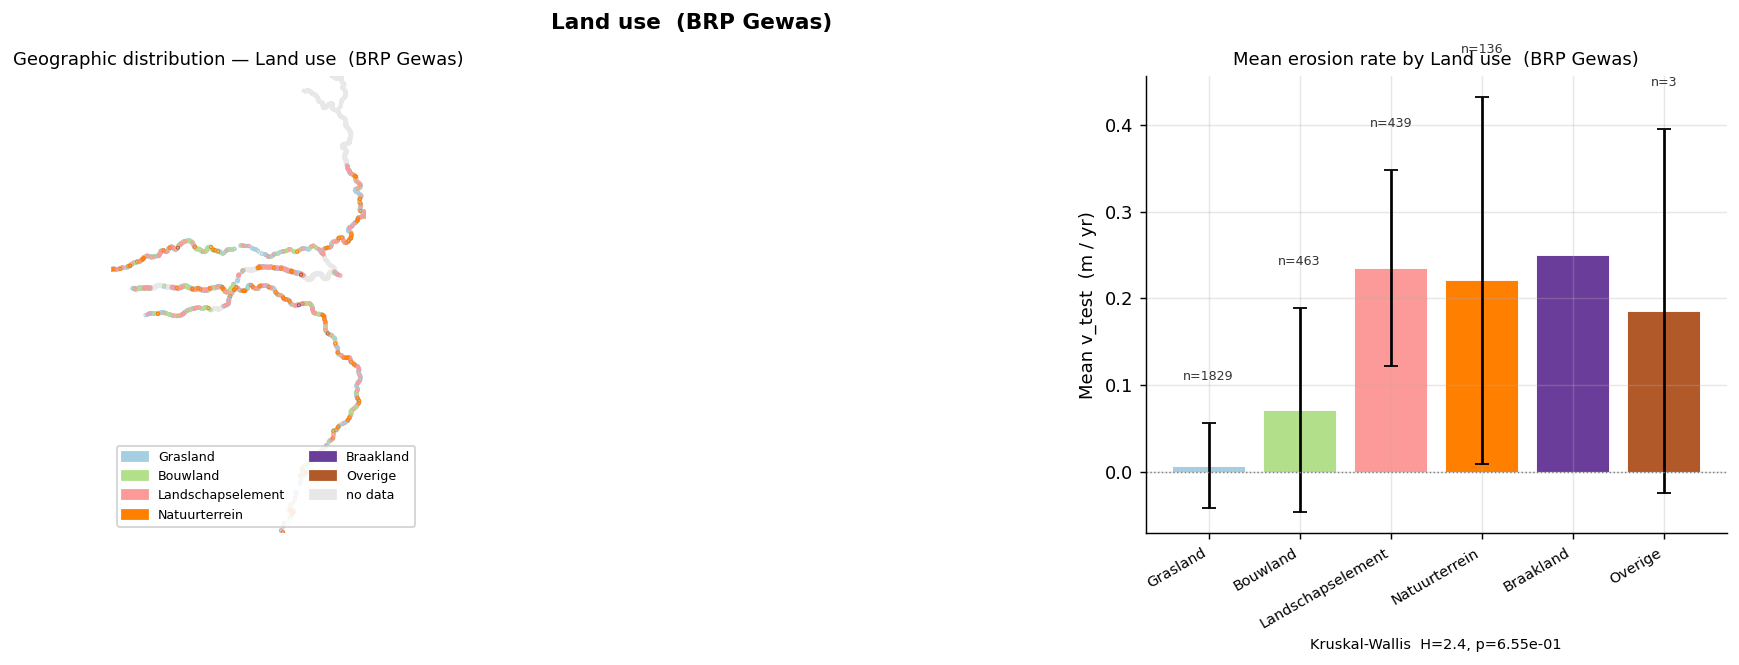

In [98]:
lu = gpd.read_file(str(LU_GPKG), layer="BrpGewas")
print(f"Land use polygons: {len(lu):,}  |  scope regions: {lu['scope_region_id'].nunique():,} / {len(features):,}")
lu["area"] = lu.geometry.area
dom_lu = (lu.sort_values("area", ascending=False)
          .groupby("scope_region_id")["category"]
          .first()
          .rename("land_use"))
features["land_use"] = features.index.map(dom_lu)
print(f"Assigned: {features['land_use'].notna().sum():,} / {len(features):,}  "
      f"({features['land_use'].notna().mean():.1%} coverage)")
print(lu["category"].value_counts().to_string())

lu_order = ["Grasland","Bouwland","Landschapselement","Natuurterrein","Braakland","Overige"]
lu_order = [v for v in lu_order if v in features["land_use"].dropna().values]
feature_overview(scope, features, col="land_use",
                 title="Land use  (BRP Gewas)", order=lu_order, cmap="Paired")


## 8 — Feature: soil type (BRO Bodemkaart)

**Source:** `01_raw/soil/BRO_DownloadBodemkaart.gpkg` — requires a spatial intersection with scope polygons.

**Soil codes are grouped** into 4 geotechnical classes based on the Dutch soil classification:
- **River clay** (`Rd*`, `Rn*`, `Ro*`) — cohesive, erosion resistant
- **Sandy** (`Z*`) — less cohesive, moderately erodible
- **Soft** (`Mv*`, `Mo*`, `b*`, peat/podzol) — low cohesion, most erodible
- **Other** (brook clay, river sand-clay, unclassified)

⚠️ Coverage note: the Bodemkaart covers land areas only. Scope polygons that extend into the river channel will have partial coverage.

In [99]:
def soil_group(code):
    """Map Dutch BRO soil unit code to a broad geotechnical group."""
    if pd.isna(code):
        return np.nan
    c = str(code)
    if c[:2] in ("Rd","Rn","Ro"):
        return "River clay"
    elif c[0] == "Z":
        return "Sandy"
    elif c[:2] in ("Mv","Mo","pM") or c[0] == "b":
        return "Soft (peat/podzol)"
    elif c[:2] == "Mn":
        return "River sand-clay"
    else:
        return "Other"

print("Loading Bodemkaart (this takes ~30s for the spatial join)...")
soil_poly  = gpd.read_file(str(SOIL_GPKG), layer="soilarea")[["maparea_id","geometry"]]
soil_codes = gpd.read_file(str(SOIL_GPKG), layer="soilarea_soilunit")[["maparea_id","soilunit_code"]]
soil_poly  = soil_poly.merge(soil_codes, on="maparea_id", how="left")
print(f"  soilarea polygons: {len(soil_poly):,}")

# Spatial intersection: scope × Bodemkaart
joined = gpd.overlay(scope.reset_index(),
                     soil_poly[["soilunit_code","geometry"]],
                     how="intersection", keep_geom_type=False)
joined["area"] = joined.geometry.area

# Dominant soil code per scope region (largest intersection area)
dominant_code = (joined.sort_values("area", ascending=False)
                 .groupby("location_id")["soilunit_code"].first())

# Coverage fraction
scope_area = scope.geometry.area.rename("scope_area")
matched_area = joined.groupby("location_id")["area"].sum()
coverage = (matched_area / scope_area).rename("soil_coverage")

features["soil_code"]  = features.index.map(dominant_code)
features["soil_group"] = features["soil_code"].map(soil_group)
features["soil_coverage"] = features.index.map(coverage)

n_assigned = features["soil_group"].notna().sum()
print(f"\nScope regions with soil group assigned: {n_assigned:,} / {len(features):,} "
      f"({n_assigned/len(features):.1%})")
print(f"Mean coverage fraction: {features['soil_coverage'].mean():.2f}  "
      f"(fraction of scope polygon area covered by Bodemkaart)")
print("\nSoil group distribution:")
print(features["soil_group"].value_counts().to_string())
print("\nTop 10 soil unit codes:")
print(features["soil_code"].value_counts().head(10).to_string())


Loading Bodemkaart (this takes ~30s for the spatial join)...
  soilarea polygons: 50,053

Scope regions with soil group assigned: 6,639 / 7,444 (89.2%)
Mean coverage fraction: 0.55  (fraction of scope polygon area covered by Bodemkaart)

Soil group distribution:
soil_group
River clay            5425
Sandy                  404
Other                  371
Soft (peat/podzol)     252
River sand-clay        187

Top 10 soil unit codes:
soil_code
Rd10A    1049
Rd90A     967
Rd90C     925
Rn95A     884
Rn52A     579
Rd10C     476
Zn30A     150
Zb20A     140
Rn82A     121
BKd25     108


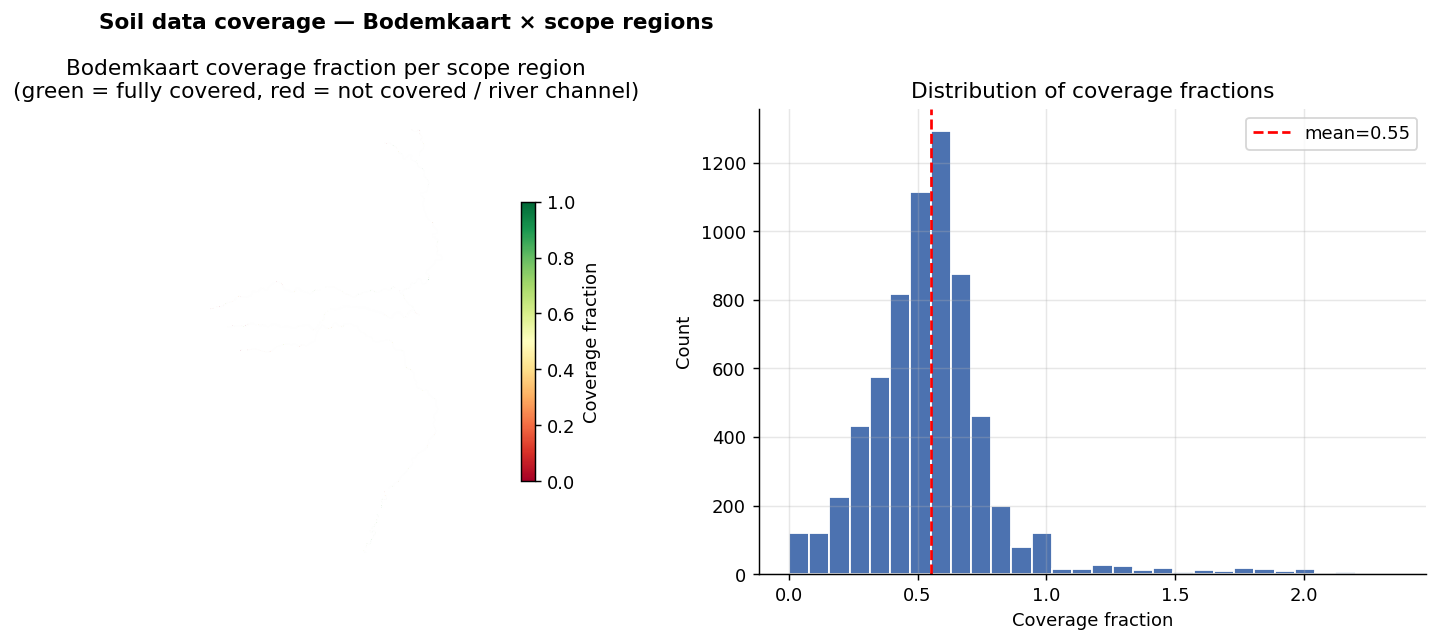

In [100]:
# Coverage map: show what fraction of each scope polygon is covered
fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
plot_gdf = scope.join(features[["soil_group","soil_coverage"]])
plot_gdf.plot(column="soil_coverage", ax=ax, cmap="RdYlGn",
              vmin=0, vmax=1, legend=True,
              legend_kwds={"label":"Coverage fraction","shrink":0.6},
              linewidth=1.2, edgecolor="white")
ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title("Bodemkaart coverage fraction per scope region\n"
             "(green = fully covered, red = not covered / river channel)")

ax = axes[1]
cov = features["soil_coverage"].dropna()
ax.hist(cov, bins=30, color="#4c72b0", edgecolor="white")
ax.axvline(cov.mean(), color="red", ls="--", lw=1.5, label=f"mean={cov.mean():.2f}")
ax.set_xlabel("Coverage fraction"); ax.set_ylabel("Count")
ax.set_title("Distribution of coverage fractions")
ax.legend()
plt.suptitle("Soil data coverage — Bodemkaart × scope regions", fontweight="bold")
plt.tight_layout(); plt.show()


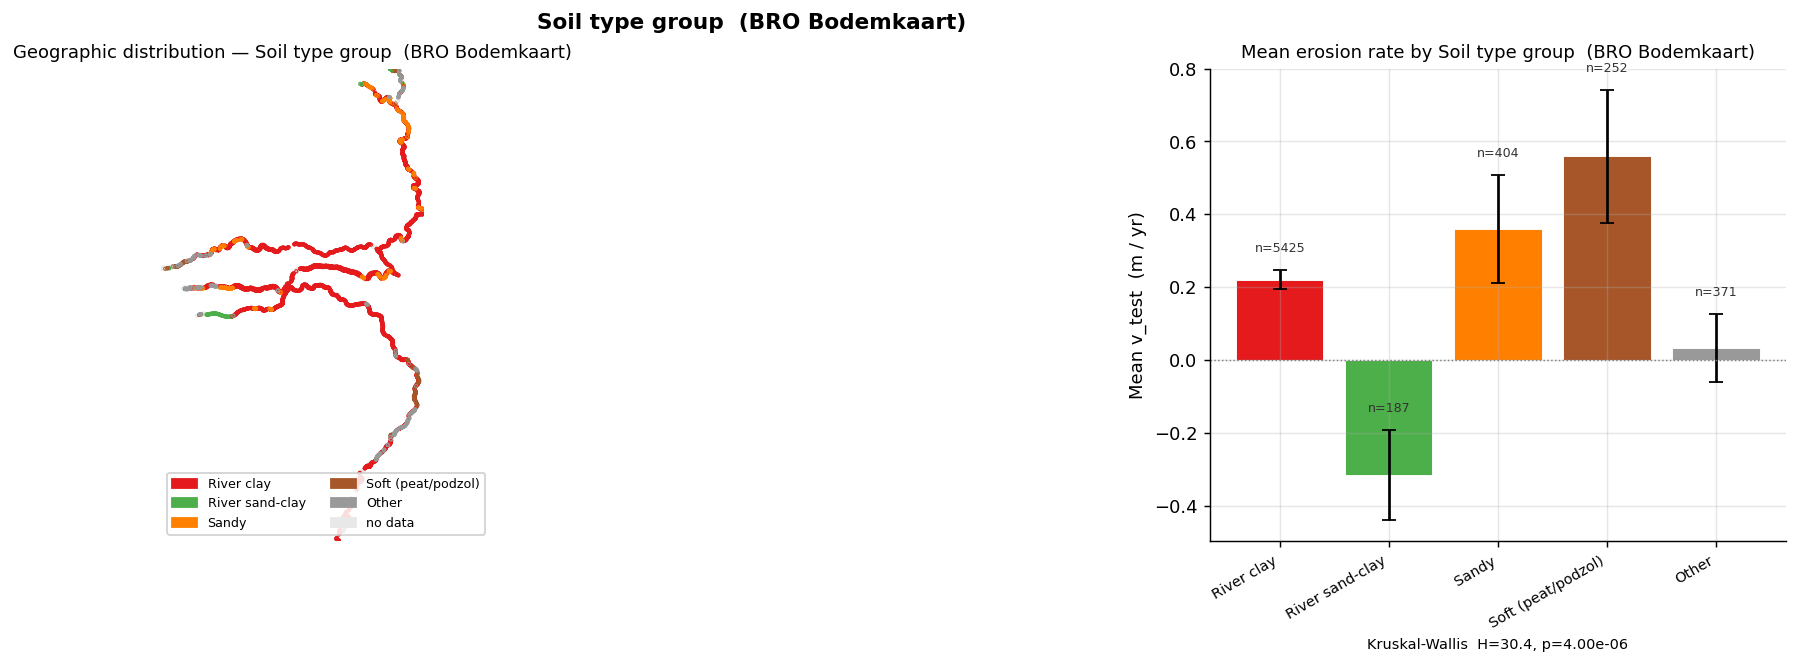

In [101]:
soil_order = ["River clay","River sand-clay","Sandy","Soft (peat/podzol)","Other"]
soil_order = [s for s in soil_order if s in features["soil_group"].dropna().values]
feature_overview(scope, features, col="soil_group",
                 title="Soil type group  (BRO Bodemkaart)",
                 order=soil_order, cmap="Set1")


## 9 — Feature: discharge at nearest gauge station

**Source:** `timeseries/discharge/*.parquet` — 10-minute discharge data from water gauge stations.

We compute per station per year: `peak_P99` (99th percentile daily max) and `days_above_P90` (flood exposure days). Then we assign each scope region its nearest discharge station and average the metric over its training window (t1→t2 years).

Anchor regions:
                          station    anchor_location_id
maastricht.borgharen.maas.beneden     maas2_l_0020_0030
                       genemuiden   ijssel2_r_2070_2080
                       megen.maas   maas3_r_15630_15640
     pannerden.pannerdenschkanaal nederrijn_l_0020_0030
        lobith.bovenrijn.tolkamer      rijn_l_0840_0844
                            venlo     maas3_r_7440_7450
                             olst   ijssel1_r_6960_6970
                          maaseik     maas2_r_3670_3680
                      driel.boven nederrijn_l_2400_2410
                  hagestein.boven nederrijn_l_7790_7800
                hank.bergschemaas   maas3_r_21300_21310
            westervoort.ijsselkop   ijssel1_l_0020_0030
               millingenaanderijn      rijn_l_1050_1060

Station assignment counts:
venlo                                1787
millingenaanderijn                   1152
westervoort.ijsselkop                1128
megen.maas                            862
olst

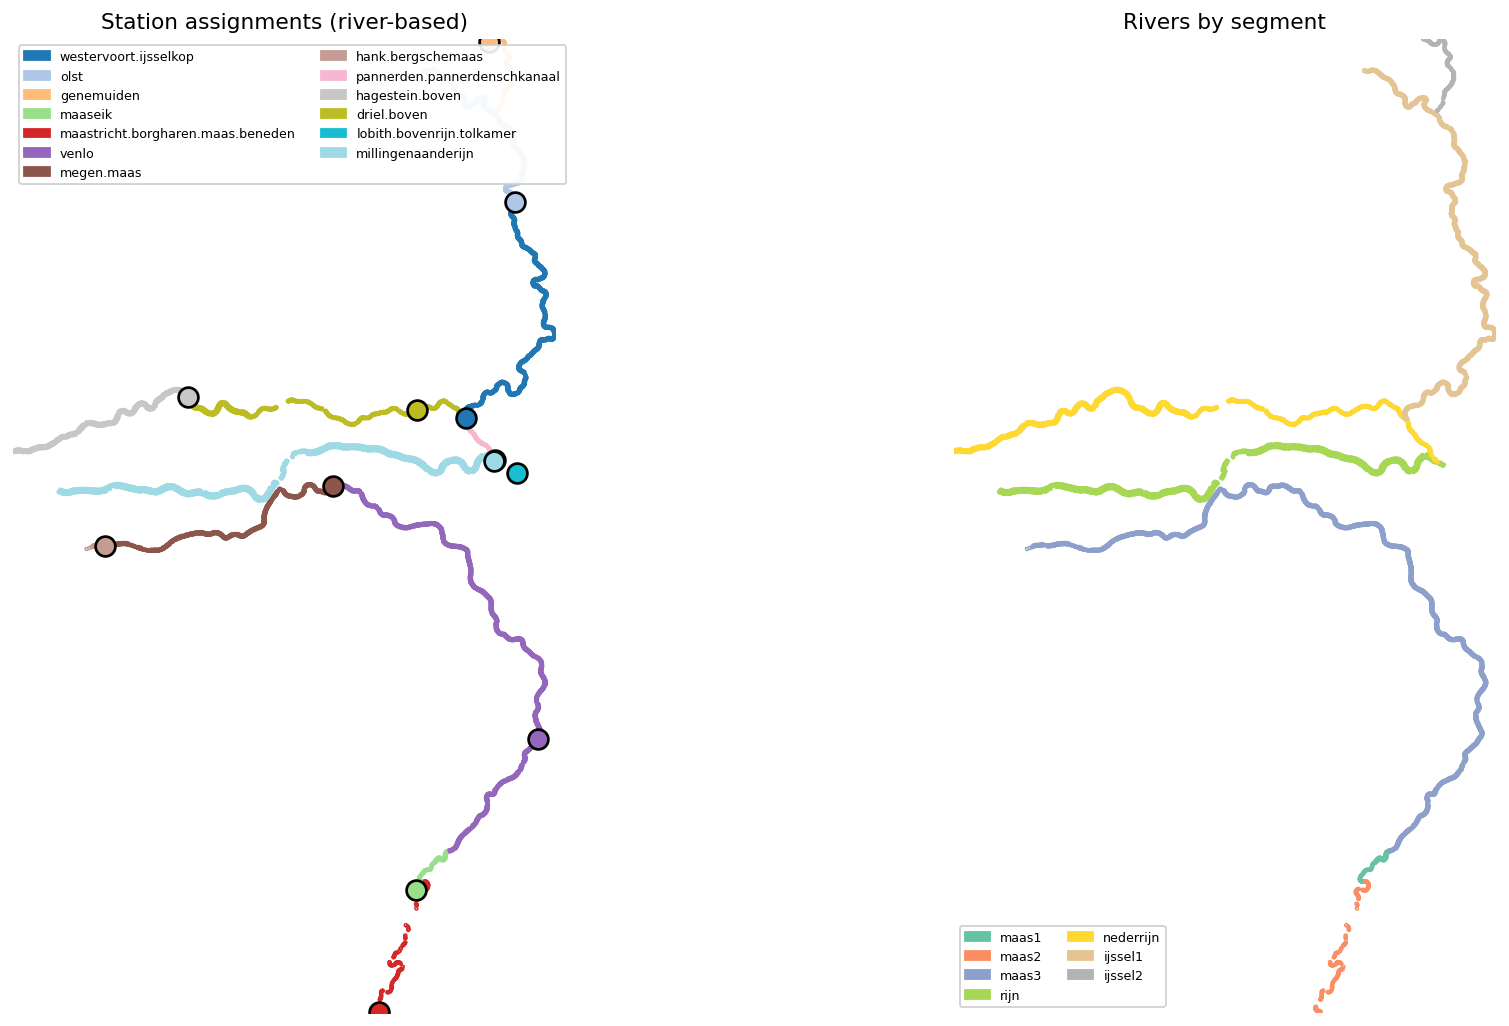

In [102]:
# Station assignment: river-based, anchor-to-anchor logic
import re
stations_rd = stations.to_crs(scope.crs)
scope_cent = gpd.GeoDataFrame(scope.copy(), geometry=scope.geometry.centroid, crs=scope.crs)

# Parse chainage from location_id (e.g. maas3_r_15630_15640 -> 15630)
def parse_chainage(loc_id):
    m = re.search(r"_(\d+)_\d+$", str(loc_id))
    return int(m.group(1)) if m else None

features["chainage"] = features.index.map(parse_chainage)

# Anchor regions: scope region whose centroid is closest to each station
def get_anchor(st):
    if st not in stations_rd.index:
        return None
    pt = stations_rd.loc[st].geometry
    dists = scope_cent.geometry.distance(pt)
    return dists.idxmin()

anchor = {st: get_anchor(st) for st in stations_rd.index if get_anchor(st)}
# Pannerden: remap anchor to most east nederrijn scope region (max x in RD)
nederrijn_regions = features[features["river"] == "nederrijn"].index
if len(nederrijn_regions):
    nederrijn_cent = scope_cent.loc[scope_cent.index.isin(nederrijn_regions)]
    most_east = nederrijn_cent.geometry.x.idxmax()
    anchor["pannerden.pannerdenschkanaal"] = most_east

# Nederrijn junction: region closest to westervoort.ijsselkop (where IJssel branches)
nederrijn_scope = scope_cent.loc[scope_cent.index.isin(nederrijn_regions)]
westervoort_pt = stations_rd.loc["westervoort.ijsselkop"].geometry
nederrijn_at_westervoort = nederrijn_scope.geometry.distance(westervoort_pt).idxmin()

# Anchor chainages for cutoffs
megen_ch = features.loc[anchor["megen.maas"], "chainage"] if anchor.get("megen.maas") else np.inf
hank_ch = features.loc[anchor["hank.bergschemaas"], "chainage"] if anchor.get("hank.bergschemaas") else np.inf
olst_ch = features.loc[anchor["olst"], "chainage"] if anchor.get("olst") else np.inf
mill_ch = features.loc[anchor["millingenaanderijn"], "chainage"] if anchor.get("millingenaanderijn") else np.inf
westervoort_ch = features.loc[nederrijn_at_westervoort, "chainage"]
hag_ch = features.loc[anchor["hagestein.boven"], "chainage"] if anchor.get("hagestein.boven") else np.inf

# Assign station per region
station_assigned = pd.Series(index=features.index, dtype=object)

for loc_id, row in features.iterrows():
    river = row["river"]
    ch = row["chainage"] if pd.notna(row["chainage"]) else 0

    if river == "maas2":
        station_assigned.loc[loc_id] = "maastricht.borgharen.maas.beneden"
    elif river == "maas1":
        station_assigned.loc[loc_id] = "maaseik"
    elif river == "maas3":
        if ch < megen_ch:
            station_assigned.loc[loc_id] = "venlo"
        elif ch < hank_ch:
            station_assigned.loc[loc_id] = "megen.maas"
        else:
            station_assigned.loc[loc_id] = "hank.bergschemaas"
    elif river == "ijssel1":
        station_assigned.loc[loc_id] = "olst" if ch >= olst_ch else "westervoort.ijsselkop"
    elif river == "ijssel2":
        station_assigned.loc[loc_id] = "genemuiden"
    elif river == "rijn":
        station_assigned.loc[loc_id] = "millingenaanderijn" if ch >= mill_ch else "lobith.bovenrijn.tolkamer"
    elif river == "nederrijn":
        if ch <= westervoort_ch:
            station_assigned.loc[loc_id] = "pannerden.pannerdenschkanaal"
        elif ch < hag_ch:
            station_assigned.loc[loc_id] = "driel.boven"
        else:
            station_assigned.loc[loc_id] = "hagestein.boven"

assign_display = features[["river", "dist_t2", "chainage"]].copy()
assign_display["station_assigned"] = station_assigned
features["station"] = station_assigned
assign_display["is_anchor"] = assign_display.index.isin(anchor.values())

anchor_df = pd.DataFrame([{"station": st, "anchor_location_id": loc} for st, loc in anchor.items()])
print("Anchor regions:")
print(anchor_df.to_string(index=False))
print(f"\nStation assignment counts:\n{station_assigned.value_counts().to_string()}")
print("\nFull assignment table (first 25 rows):")
print(assign_display.head(25).to_string())

# Two-panel figure: map (left) + rivers (right)
station_order = assign_display["station_assigned"].dropna().unique().tolist()
colors = dict(zip(station_order, plt.cm.get_cmap("tab20", len(station_order)).colors))
plot_scope = scope.join(assign_display[["station_assigned"]])
plot_scope["station_assigned"] = plot_scope["station_assigned"].fillna("(unassigned)")

fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [1.5, 1]})
ax_map, ax_rivers = axes[0], axes[1]

# Left: map
xmin, ymin, xmax, ymax = scope.total_bounds
ax_map.set_xlim(xmin, xmax)
ax_map.set_ylim(ymin, ymax)
ax_map.set_aspect(1)
scope.plot(ax=ax_map, color="#e8e8e8", linewidth=2, edgecolor="#e8e8e8")
for st in station_order:
    sub = plot_scope[plot_scope["station_assigned"] == st]
    if len(sub):
        sub.plot(ax=ax_map, color=colors[st], linewidth=2, edgecolor=colors[st])
# Station dots
for st in station_order:
    if st in stations_rd.index:
        pt = stations_rd.loc[st].geometry
        ax_map.scatter(pt.x, pt.y, s=120, c=[colors[st]], edgecolor="black", linewidths=1.5, zorder=5)
ax_map.set_axis_off()
ax_map.set_title("Station assignments (river-based)")
handles_map = [mpatches.Patch(color=colors[st], label=st) for st in station_order]
ax_map.legend(handles=handles_map, loc="upper left", fontsize=7, framealpha=0.9, ncol=2)

# Right: map with rivers highlighted in colors
river_order = [r for r in ["maas1", "maas2", "maas3", "rijn", "nederrijn", "ijssel1", "ijssel2"]
               if r in features["river"].unique()]
river_colors = dict(zip(river_order, plt.cm.get_cmap("Set2", len(river_order)).colors))
plot_rivers = scope.join(features[["river"]])
ax_rivers.set_xlim(xmin, xmax)
ax_rivers.set_ylim(ymin, ymax)
ax_rivers.set_aspect(1)
scope.plot(ax=ax_rivers, color="#e8e8e8", linewidth=2, edgecolor="#e8e8e8")
for river in river_order:
    sub = plot_rivers[plot_rivers["river"] == river]
    if len(sub):
        sub.plot(ax=ax_rivers, color=river_colors[river], linewidth=2, edgecolor=river_colors[river])
ax_rivers.set_axis_off()
ax_rivers.set_title("Rivers by segment")
ax_rivers.legend(handles=[mpatches.Patch(color=river_colors[r], label=r) for r in river_order],
                loc="lower left", fontsize=7, framealpha=0.9, ncol=2)
plt.tight_layout()
plt.show()

In [104]:
# This one! — High-water thresholds (m³/s) per discharge station
# From 02c_eda_clean_discharge.ipynb; used for SPI, n_events, max_rise_rate, drawdown_index
HIGH_WATER_THRESHOLD = {
    "lobith.bovenrijn.tolkamer": 6000,
    "millingenaanderijn": 4000,
    "pannerden.pannerdenschkanaal": 2000,
    "driel.boven": 1000,
    "hagestein.boven": 1000,
    "maastricht.borgharen.maas.beneden": 1000,
    "maaseik": 1000,
    "venlo": 1000,
    "megen.maas": 1000,
    "hank.bergschemaas": 1100,
    "westervoort.ijsselkop": 800,
    "westervoort": 800,
    "olst": 800,
    "genemuiden": 300,
}

In [105]:
print("Loading discharge timeseries...")
disc_all = []
for f in sorted(DISCHARGE_DIR.glob("*.parquet")):
    df_ = pd.read_parquet(f)
    df_["timestamp"] = pd.to_datetime(df_["timestamp"], utc=True)
    disc_all.append(df_)
disc = pd.concat(disc_all, ignore_index=True)
disc["date"] = disc["timestamp"].dt.date
disc_daily = disc.groupby(["station_code", "date"])["discharge_m3s"].max().reset_index()
disc_daily["year"] = pd.to_datetime(disc_daily["date"]).dt.year
print(f"  Daily discharge records: {len(disc_daily):,}")
print(f"  Stations: {disc_daily['station_code'].unique().tolist()}")

# Annual days-above-p90 per station
# p90 is computed over the full record per station (station-relative intensity)
station_annual = {}
for code, grp in disc_daily.groupby("station_code"):
    p90 = grp["discharge_m3s"].quantile(0.90)
    station_annual[code] = grp.groupby("year").agg(
        days_above_p90=("discharge_m3s", lambda x: (x > p90).sum()),
    )

# Extract training-window mean per region
def disc_stats(row):
    code = row.get("station")
    nan_out = pd.Series({"days_above_p90": np.nan})
    if pd.isna(code) or code not in station_annual:
        return nan_out
    ann = station_annual[code]
    t1, t2 = row.get("t1", np.nan), row.get("t2", np.nan)
    window = ann.loc[ann.index.isin(range(int(t1), int(t2) + 1))] if not pd.isna(t1) else ann
    if window.empty:
        return nan_out
    return pd.Series({"days_above_p90": window["days_above_p90"].mean()})

print("Computing discharge stats per region...")
disc_feat = features.join(split[["t1", "t2"]]).apply(disc_stats, axis=1)
features = features.drop(columns=["days_above_p90"], errors="ignore").join(disc_feat)
print(f"Discharge assigned: {features['days_above_p90'].notna().sum():,} / {len(features):,}")
print(f"\nStation assignments:\n{features['station'].value_counts().to_string()}")

Loading discharge timeseries...
  Daily discharge records: 42,721
  Stations: ['driel.boven', 'genemuiden', 'hagestein.boven', 'hank.bergschemaas', 'lobith.bovenrijn.tolkamer', 'maaseik', 'maastricht.borgharen.maas.beneden', 'megen.maas', 'millingenaanderijn', 'olst', 'pannerden.pannerdenschkanaal', 'venlo', 'westervoort', 'westervoort.ijsselkop']
Computing discharge stats per region...
Discharge assigned: 7,444 / 7,444

Station assignments:
station
venlo                                1787
millingenaanderijn                   1152
westervoort.ijsselkop                1128
megen.maas                            862
olst                                  682
driel.boven                           596
hagestein.boven                       527
genemuiden                            287
maastricht.borgharen.maas.beneden     178
maaseik                               127
pannerden.pannerdenschkanaal           75
hank.bergschemaas                      32
lobith.bovenrijn.tolkamer              11


In [106]:
# High-water metrics per station per calendar year (10-min resolution)
# Uses HIGH_WATER_THRESHOLD; output: DataFrame (station_id, year) with n_events, max_rise_rate, drawdown_index
# SPI is computed but excluded from features — collinear with n_events and adds no within-segment variance

DT_HOURS = 1 / 6  # 10-minute interval in hours
GAP_HOURS = 72    # Bridge gaps below threshold shorter than this (same event)

def compute_high_water_metrics(station_code: str, df: pd.DataFrame, q_thresh: float) -> pd.DataFrame:
    """Compute spi, n_events, max_rise_rate, drawdown_index per calendar year."""
    df = df.sort_values("timestamp").copy()
    df["year"] = df["timestamp"].dt.year
    df["exceed"] = df["discharge_m3s"] > q_thresh
    df["excess"] = np.maximum(df["discharge_m3s"] - q_thresh, 0)
    df["dQ"] = df["discharge_m3s"].diff()
    df["dt_h"] = df["timestamp"].diff().dt.total_seconds() / 3600
    df["dQ_dt"] = np.where(df["dt_h"] > 0, df["dQ"] / df["dt_h"], np.nan)

    rows = []
    for year, grp in df.groupby("year"):
        g = grp.dropna(subset=["discharge_m3s"]).sort_values("timestamp")
        if g.empty:
            rows.append({"station_id": station_code, "year": year, "spi": np.nan, "n_events": np.nan,
                         "max_rise_rate": np.nan, "drawdown_index": np.nan})
            continue

        # SPI: sum(max(Q - Q_thresh, 0)^1.5) * dt_hours (use actual dt per row)
        dt_h = g["timestamp"].diff().dt.total_seconds() / 3600
        dt_h = dt_h.fillna(DT_HOURS)  # first row
        spi = (g["excess"] ** 1.5 * dt_h).sum()

        # Event detection: exceedance periods, bridge gaps < 72h
        exceed = g["exceed"].values
        ts = pd.to_datetime(g["timestamp"])
        blocks = []
        i = 0
        while i < len(exceed):
            if exceed[i]:
                start = i
                while i < len(exceed) and exceed[i]:
                    i += 1
                blocks.append((ts.iloc[start], ts.iloc[i - 1]))
            else:
                i += 1
        # Merge blocks separated by gap < 72h
        merged = []
        for t0, t1 in blocks:
            if merged and (t0 - merged[-1][1]).total_seconds() / 3600 < GAP_HOURS:
                merged[-1] = (merged[-1][0], t1)
            else:
                merged.append((t0, t1))
        n_events = len(merged)

        # max_rise_rate: max dQ/dt during exceedance (positive gradient)
        rise_mask = g["exceed"] & (g["dQ_dt"] > 0)
        max_rise = g.loc[rise_mask, "dQ_dt"].max() if rise_mask.any() else np.nan

        # drawdown_index: max |dQ/dt| during recession (negative gradient, within exceedance)
        recession_mask = g["exceed"] & (g["dQ_dt"] < 0)
        drawdown = np.abs(g.loc[recession_mask, "dQ_dt"]).max() if recession_mask.any() else np.nan

        rows.append({"station_id": station_code, "year": year, "spi": spi, "n_events": n_events,
                     "max_rise_rate": max_rise, "drawdown_index": drawdown})

    return pd.DataFrame(rows)

# Prefer cleaned discharge if available
_CLEANED = PATHS.DATA_DIR / "water_stations_timeseries" / "cleaned" / "discharge"
_DISC_DIR = _CLEANED if _CLEANED.exists() and list(_CLEANED.glob("*.parquet")) else DISCHARGE_DIR
print(f"Using discharge from: {_DISC_DIR}")

disc_10min = []
for f in sorted(_DISC_DIR.glob("*.parquet")):
    df_ = pd.read_parquet(f)
    df_["timestamp"] = pd.to_datetime(df_["timestamp"], utc=True)
    disc_10min.append(df_)
disc_raw = pd.concat(disc_10min, ignore_index=True)

# Compute metrics for each station with a threshold
hw_results = []
for code, thresh in HIGH_WATER_THRESHOLD.items():
    sub = disc_raw[disc_raw["station_code"] == code]
    if sub.empty:
        continue
    hw_results.append(compute_high_water_metrics(code, sub, thresh))

hw_metrics = pd.concat(hw_results, ignore_index=True)
hw_metrics = hw_metrics.set_index(["station_id", "year"])
print(f"High-water metrics: {len(hw_metrics):,} (station, year) rows")
print(hw_metrics.head(12))

# Per-region: mean of hw metrics over training window (t1..t2)
# SPI excluded from features — collinear with n_events and adds no within-segment variance
HW_FEATURE_COLS = ["n_events", "max_rise_rate", "drawdown_index"]

def hw_stats(row):
    code = row.get("station")
    nan_out = pd.Series({c: np.nan for c in HW_FEATURE_COLS})
    if pd.isna(code) or code not in hw_metrics.index.get_level_values(0):
        return nan_out
    t1, t2 = row.get("t1", np.nan), row.get("t2", np.nan)
    years = list(range(int(t1), int(t2) + 1)) if not pd.isna(t1) and not pd.isna(t2) else []
    try:
        sub = hw_metrics.loc[code]
    except KeyError:
        return nan_out
    sub = sub.to_frame().T if isinstance(sub, pd.Series) else sub
    if years:
        sub = sub.loc[sub.index.intersection(years)]
    if len(sub) == 0:
        return nan_out
    return pd.Series({c: sub[c].mean() for c in HW_FEATURE_COLS})

hw_feat = features.join(split[["t1", "t2"]]).apply(hw_stats, axis=1)
features = features.drop(columns=HW_FEATURE_COLS, errors="ignore").join(hw_feat)

# Zero-fill for any station with no detected high-water events (e.g. Genemuiden, IJssel2)
# NaN here means "no events occurred", which is informative — not missing data
no_events_mask = features[HW_FEATURE_COLS].isna().all(axis=1)
features.loc[no_events_mask, HW_FEATURE_COLS] = 0

print(f"\nHW metrics assigned: {features['n_events'].notna().sum():,} / {len(features):,}")
print(f"Regions with no high-water events (hw=0): {no_events_mask.sum():,}")
print("\nStations with zero hw metrics:")
print(features.loc[no_events_mask, ["station"] + HW_FEATURE_COLS].groupby("station").size())

Using discharge from: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaned/discharge
High-water metrics: 136 (station, year) rows
                                         spi  n_events  max_rise_rate  \
station_id                year                                          
lobith.bovenrijn.tolkamer 2015  0.000000e+00         0            NaN   
                          2016  0.000000e+00         0            NaN   
                          2017  0.000000e+00         0            NaN   
                          2018  5.633287e+06         2         300.60   
                          2019  0.000000e+00         0            NaN   
                          2020  1.892431e+04         1         221.04   
                          2021  7.299351e+06         2         295.62   
                          2022  0.000000e+00         0            NaN   
                          2023  3.920678e+06         1         358.38   
        

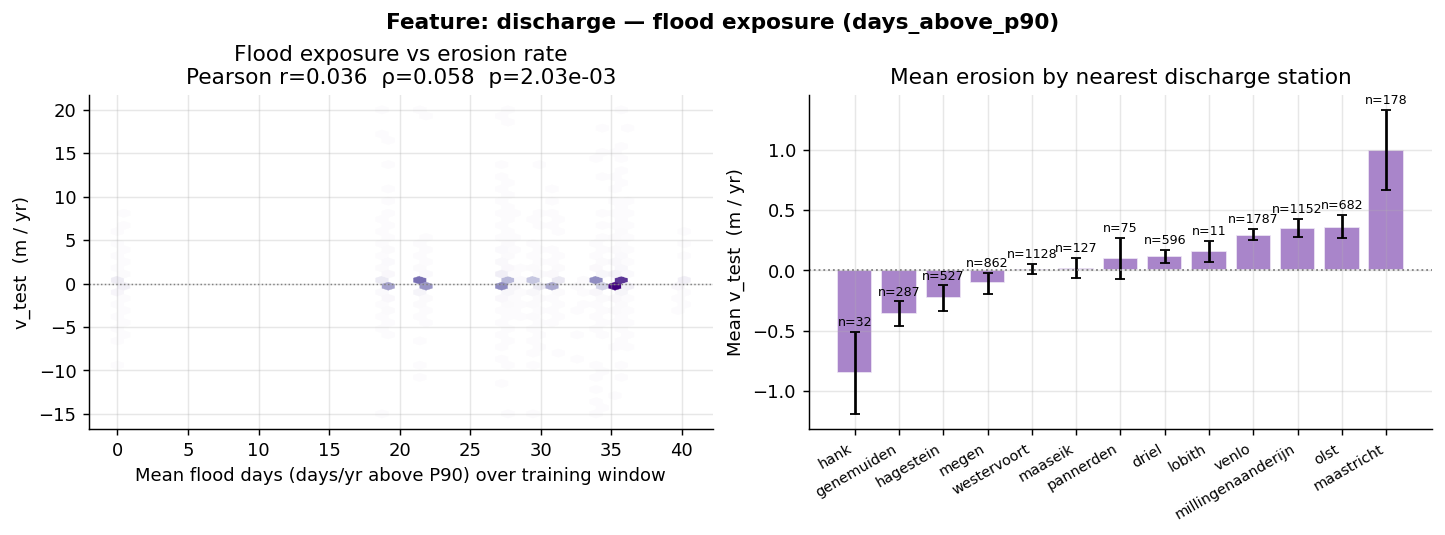

In [110]:
# days_above_p90: flood exposure (days/yr discharge > P90, avg over training window)
DISC_COL = "days_above_p90"
st_col = "station" if "station" in features.columns else "nearest_station"
df = features.dropna(subset=["v_test", DISC_COL])
r_disc, p_disc = stats.pearsonr(df[DISC_COL], df["v_test"])
rho_disc, p_rho = stats.spearmanr(df[DISC_COL], df["v_test"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax = axes[0]
ax.hexbin(df[DISC_COL], df["v_test"].clip(-15, 20), gridsize=45,
          cmap="Purples", mincnt=1, linewidths=0.2)
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("Mean flood days (days/yr above P90) over training window")
ax.set_ylabel("v_test  (m / yr)")
ax.set_title(f"Flood exposure vs erosion rate\nPearson r={r_disc:.3f}  ρ={rho_disc:.3f}  p={p_disc:.2e}")

ax = axes[1]
st_stats = df.groupby(st_col)["v_test"].agg(mean="mean", sem=lambda x: x.sem(), n="count").sort_values("mean")
x = np.arange(len(st_stats))
ax.bar(x, st_stats["mean"], yerr=st_stats["sem"], capsize=3,
       color="#9467bd", edgecolor="white", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([str(s).split(".")[0] for s in st_stats.index], rotation=30, ha="right", fontsize=8)
ax.axhline(0, color="grey", lw=1, ls=":")
ax.set_ylabel("Mean v_test  (m / yr)")
ax.set_title("Mean erosion by nearest discharge station")
for xi, (_, row) in enumerate(st_stats.iterrows()):
    ax.text(xi, row["mean"] + row["sem"] + 0.05, f"n={int(row['n'])}", ha="center", fontsize=7)

plt.suptitle("Feature: discharge — flood exposure (days_above_p90)", fontweight="bold")
plt.show()


In [123]:
# High-water metrics by measurement window: average during years BETWEEN t1↔t2 and t2↔t3
# e.g. measurements at 2016, 2019, 2023 → t1 window: 2017–2018, t2 window: 2020–2022
# Metrics: n_events, max_rise_rate, drawdown_index, flood_days (days_above_p90)
HW_METRIC_COLS = ["n_events", "max_rise_rate", "drawdown_index"]
st_col = "station" if "station" in features.columns else "nearest_station"

def hw_window_stats(row):
    """Mean of hw metrics over years between measurements (exclusive of measurement years)."""
    code = row.get(st_col)
    t1, t2, t3 = row.get("t1"), row.get("t2"), row.get("t3")
    nan_out = pd.Series({
        f"{c}_t1": np.nan for c in HW_METRIC_COLS
    } | {f"{c}_t2": np.nan for c in HW_METRIC_COLS} | {"flood_days_t1": np.nan, "flood_days_t2": np.nan})
    if pd.isna(code):
        return nan_out
    t1_ok = not (pd.isna(t1) or pd.isna(t2)) and int(t2) - int(t1) > 1
    t2_ok = not (pd.isna(t2) or pd.isna(t3)) and int(t3) - int(t2) > 1
    years_t1 = list(range(int(t1) + 1, int(t2))) if t1_ok else []
    years_t2 = list(range(int(t2) + 1, int(t3))) if t2_ok else []

    out = {}
    # HW metrics from hw_metrics
    if code in hw_metrics.index.get_level_values(0):
        try:
            sub = hw_metrics.loc[code]
            sub = sub.to_frame().T if isinstance(sub, pd.Series) else sub
            for c in HW_METRIC_COLS:
                if years_t1:
                    sub_t1 = sub.loc[sub.index.intersection(years_t1)]
                    out[f"{c}_t1"] = sub_t1[c].mean() if len(sub_t1) > 0 else np.nan
                else:
                    out[f"{c}_t1"] = np.nan
                if years_t2:
                    sub_t2 = sub.loc[sub.index.intersection(years_t2)]
                    out[f"{c}_t2"] = sub_t2[c].mean() if len(sub_t2) > 0 else np.nan
                else:
                    out[f"{c}_t2"] = np.nan
        except KeyError:
            for c in HW_METRIC_COLS:
                out[f"{c}_t1"] = out[f"{c}_t2"] = np.nan
    else:
        for c in HW_METRIC_COLS:
            out[f"{c}_t1"] = out[f"{c}_t2"] = np.nan

    # flood_days (days_above_p90) from station_annual
    try:
        if code in station_annual and station_annual[code] is not None:
            ann = station_annual[code]
            sub_t1 = ann.loc[ann.index.intersection(years_t1)] if years_t1 else pd.DataFrame()
            sub_t2 = ann.loc[ann.index.intersection(years_t2)] if years_t2 else pd.DataFrame()
            out["flood_days_t1"] = sub_t1["days_above_p90"].mean() if len(sub_t1) > 0 else np.nan
            out["flood_days_t2"] = sub_t2["days_above_p90"].mean() if len(sub_t2) > 0 else np.nan
        else:
            out["flood_days_t1"] = out["flood_days_t2"] = np.nan
    except NameError:
        out["flood_days_t1"] = out["flood_days_t2"] = np.nan

    return pd.Series(out)

WINDOW_COLS = [f"{c}_t1" for c in HW_METRIC_COLS] + [f"{c}_t2" for c in HW_METRIC_COLS] + ["flood_days_t1", "flood_days_t2"]
hw_window_feat = features.join(split[["t1", "t2", "t3"]]).apply(hw_window_stats, axis=1)
features = features.drop(columns=WINDOW_COLS, errors="ignore").join(hw_window_feat)
n_t1 = features[[c for c in WINDOW_COLS if c.endswith("_t1")]].notna().all(axis=1).sum()
n_t2 = features[[c for c in WINDOW_COLS if c.endswith("_t2")]].notna().all(axis=1).sum()
print(f"HW window metrics: t1={n_t1:,} / t2={n_t2:,} regions with full data")

# 5 example regions — dataframe
example_cols = ["t1", "t2", "t3", "v_train", "v_test"] + WINDOW_COLS
has_full = features[WINDOW_COLS].notna().all(axis=1)
examples = features.loc[has_full].join(split[["t1", "t2", "t3"]]).head(5)[example_cols]
examples.index.name = "location_id"
print("\n5 example regions (full window data):")
display(examples.round(4))

HW window metrics: t1=7,444 / t2=7,444 regions with full data

5 example regions (full window data):


,t1,t2,t3,v_train,v_test,n_events_t1,max_rise_rate_t1,drawdown_index_t1,n_events_t2,max_rise_rate_t2,drawdown_index_t2,flood_days_t1,flood_days_t2
location_id,,,,,,,,,,,,,
ijssel1_l_0010_0020,2017,2022,2025,0.1502,0.1669,0.5,2.5,4.375,2.0,3.6908,3.4829,22.75,62.0
ijssel1_l_0020_0030,2017,2022,2025,0.0167,-0.0556,0.5,2.5,4.375,2.0,3.6908,3.4829,22.75,62.0
ijssel1_l_0050_0056,2017,2022,2025,-0.0833,-0.5556,0.5,2.5,4.375,2.0,3.6908,3.4829,22.75,62.0
ijssel1_l_0060_0070,2017,2022,2025,0.3505,-0.8624,0.5,2.5,4.375,2.0,3.6908,3.4829,22.75,62.0
ijssel1_l_0070_0080,2017,2022,2025,0.0334,0.0000,0.5,2.5,4.375,2.0,3.6908,3.4829,22.75,62.0


## 10 — Feature: river geometry / bend position

**Source:** `get_nearby_linestring_shape` from `src.utils` (same logic as DataHandler's `centerline_shape`).

Measures how much the river centerline bends near each scope region: cosine similarity of direction vectors from the projected point to upstream/downstream neighbours. Straight = 0; outer bends (erosion-prone) have higher values.

In [115]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Load curvature features from region_features_v2
# ══════════════════════════════════════════════════════════════════════════════

from src.data.curvature import curvature_feature_cols

FEATURES_V2_PATH = PATHS.DATA_DIR / "02_processed/erosion/region_features_v2.parquet"

if FEATURES_V2_PATH.exists():
    feat_v2   = pd.read_parquet(FEATURES_V2_PATH)
    curv_cols = curvature_feature_cols()          # all 9 columns (3 scales × 3 types)
    features[curv_cols] = feat_v2[curv_cols].reindex(features.index).values
    n_ok = features[curv_cols].notna().all(axis=1).sum()
    print(f"Curvature loaded: {n_ok:,} / {len(features):,} regions "
          f"({n_ok / len(features) * 100:.1f}%) fully populated")
    print(f"  Columns: {curv_cols}")
    display(features[curv_cols].describe().round(6))
else:
    print(f"region_features_v2 not found: {FEATURES_V2_PATH}")




Curvature loaded: 7,444 / 7,444 regions (100.0%) fully populated
  Columns: ['curvature_n3', 'curvature_n5', 'curvature_n8', 'bend_side_n3', 'bend_side_n5', 'bend_side_n8', 'bend_exposure_n3', 'bend_exposure_n5', 'bend_exposure_n8']


,curvature_n3,curvature_n5,curvature_n8,bend_side_n3,bend_side_n5,bend_side_n8,bend_exposure_n3,bend_exposure_n5,bend_exposure_n8
count,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000
mean,0.000259,0.000225,0.000186,0.022300,0.018538,0.015046,-0.000014,-0.000010,-0.000006
std,0.000227,0.000192,0.000157,0.997935,0.998012,0.998071,0.000344,0.000296,0.000243
min,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-0.002042,-0.001315,-0.000934
25%,0.000088,0.000080,0.000067,-1.000000,-1.000000,-1.000000,-0.000196,-0.000176,-0.000143
50%,0.000194,0.000172,0.000142,1.000000,1.000000,1.000000,0.000005,0.000005,0.000003
75%,0.000376,0.000322,0.000267,1.000000,1.000000,1.000000,0.000192,0.000170,0.000139
max,0.002042,0.001315,0.000934,1.000000,1.000000,1.000000,0.001222,0.000963,0.000759


Correlations with v_test — all curvature features

Feature                System           n   Pearson r   p_pearson  Spearman ρ     p_spear
────────────────────────────────────────────────────────────────────────────────
bend_exposure_n3       Maas          2986     +0.0260    1.55e-01     +0.0253    1.68e-01
bend_exposure_n3       Rijntakken    4458     +0.0116    4.40e-01     +0.0161    2.82e-01
bend_exposure_n5       Maas          2986     +0.0260    1.55e-01     +0.0276    1.31e-01
bend_exposure_n5       Rijntakken    4458     +0.0072    6.31e-01     +0.0122    4.17e-01
bend_exposure_n8       Maas          2986     +0.0181    3.23e-01     +0.0243    1.83e-01
bend_exposure_n8       Rijntakken    4458     +0.0046    7.60e-01     +0.0054    7.19e-01
curvature_n3           Maas          2986     +0.0262    1.52e-01     +0.0050    7.87e-01
curvature_n3           Rijntakken    4458     -0.0454    2.42e-03     -0.0631    2.48e-05
curvature_n5           Maas          2986     +0.0269    1

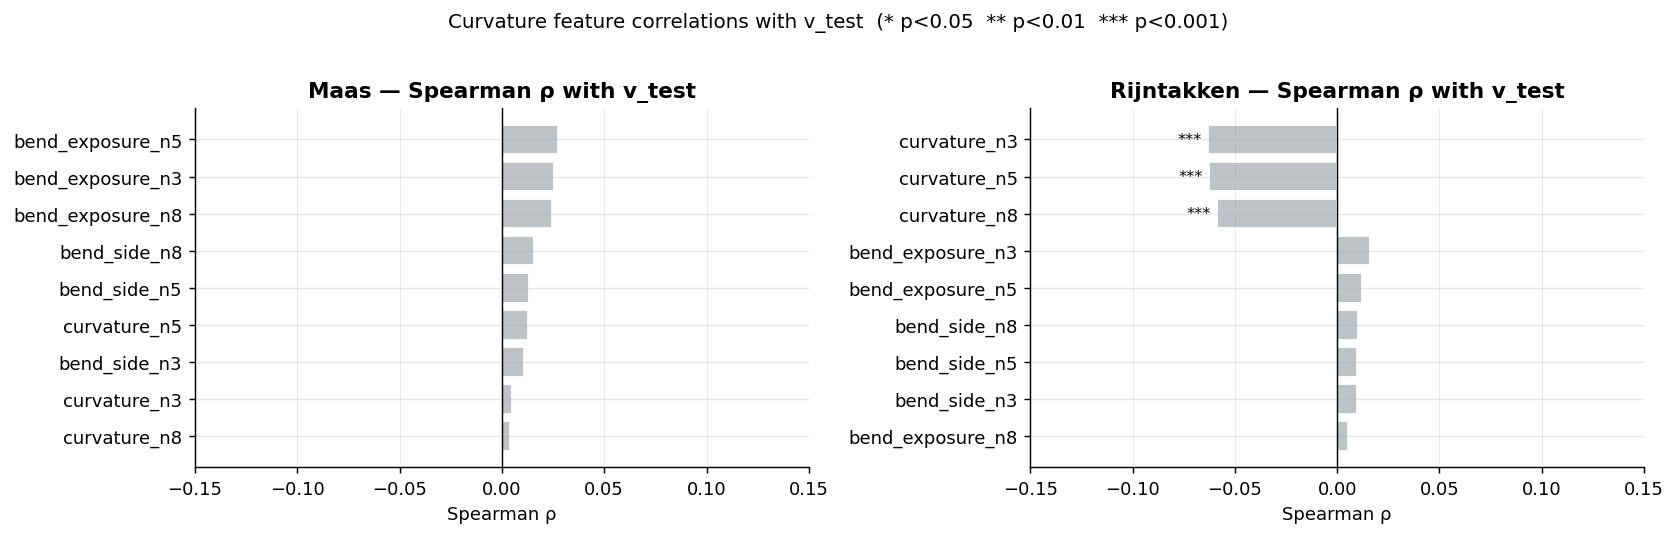

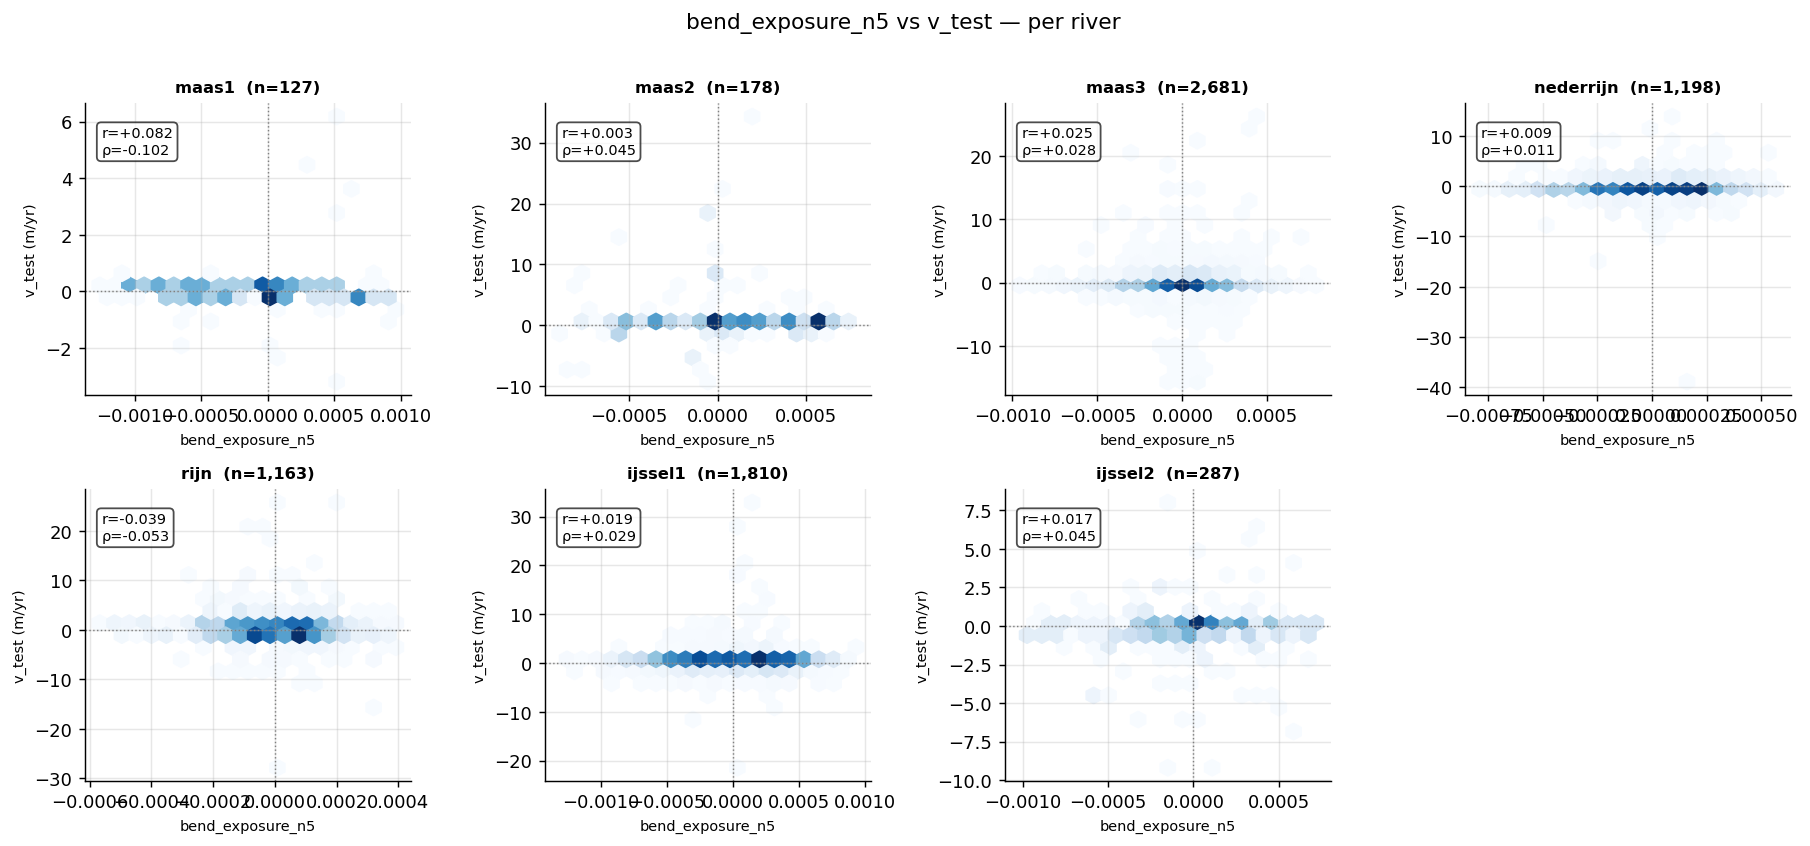

In [116]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Multi-scale curvature diagnostics
# Compare n3 / n5 / n8 correlations with v_test; confirm n3 is noisiest
# ══════════════════════════════════════════════════════════════════════════════

SCALES         = [3, 5, 8]
EXPOSURE_COLS  = [f"bend_exposure_n{n}" for n in SCALES]
CURV_COLS_PLOT = [f"curvature_n{n}" for n in SCALES]
SIDE_COLS      = [f"bend_side_n{n}" for n in SCALES]

maas_mask = features["river"].isin(["maas1", "maas2", "maas3"])
systems   = {"Maas": maas_mask, "Rijntakken": ~maas_mask}

# ── 2a: Pearson + Spearman correlation with v_test per scale per system ──────
print("Correlations with v_test — all curvature features\n")
print(f"{'Feature':<22} {'System':<12} {'n':>5}  "
      f"{'Pearson r':>10}  {'p_pearson':>10}  {'Spearman ρ':>10}  {'p_spear':>10}")
print("─" * 80)

corr_rows = []
for col in EXPOSURE_COLS + CURV_COLS_PLOT + SIDE_COLS:
    for sys_name, mask in systems.items():
        sub = features.loc[mask].dropna(subset=[col, "v_test"])
        if len(sub) < 10:
            continue
        r,   p_r   = stats.pearsonr(sub[col], sub["v_test"])
        rho, p_rho = stats.spearmanr(sub[col], sub["v_test"])
        print(f"{col:<22} {sys_name:<12} {len(sub):>5}  "
              f"{r:>+10.4f}  {p_r:>10.2e}  {rho:>+10.4f}  {p_rho:>10.2e}")
        corr_rows.append(dict(feature=col, system=sys_name, n=len(sub),
                              pearson_r=r, p_pearson=p_r,
                              spearman_rho=rho, p_spearman=p_rho))
print()
corr_summary = pd.DataFrame(corr_rows)


# ── 2b: Bar chart — Spearman ρ with v_test for all curvature features ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
colors = {"Maas": "#d73027", "Rijntakken": "#4575b4"}

for ax, (sys_name, mask) in zip(axes, systems.items()):
    sub = corr_summary[corr_summary["system"] == sys_name].copy()
    sub = sub.sort_values("spearman_rho", key=abs, ascending=True)
    bar_colors = [
        "#c0392b" if abs(v) > 0.1 and v < 0 else
        "#2980b9" if abs(v) > 0.1 and v > 0 else
        "#bdc3c7"
        for v in sub["spearman_rho"]
    ]
    bars = ax.barh(sub["feature"], sub["spearman_rho"], color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", lw=0.8)
    # Significance markers
    for bar, (_, row) in zip(bars, sub.iterrows()):
        sig = "***" if row["p_spearman"] < 0.001 else "**" if row["p_spearman"] < 0.01 else "*" if row["p_spearman"] < 0.05 else ""
        if sig:
            x = row["spearman_rho"]
            ax.text(x + (0.003 if x >= 0 else -0.003), bar.get_y() + bar.get_height() / 2,
                    sig, va="center", ha="left" if x >= 0 else "right", fontsize=9, color="black")
    ax.set_title(f"{sys_name} — Spearman ρ with v_test", fontweight="bold")
    ax.set_xlabel("Spearman ρ")
    ax.set_xlim(
        min(-0.15, sub["spearman_rho"].min() - 0.02),
        max(0.15,  sub["spearman_rho"].max() + 0.02),
    )
    ax.grid(axis="x", alpha=0.3, lw=0.5)

plt.suptitle("Curvature feature correlations with v_test  (* p<0.05  ** p<0.01  *** p<0.001)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


# ── 2c: Scatter grid — bend_exposure_n5 vs v_test per river ─────────────────
rivers_ordered = ["maas1", "maas2", "maas3", "nederrijn", "rijn", "ijssel1", "ijssel2"]
rivers_present = [r for r in rivers_ordered if r in features["river"].values]
n_riv = len(rivers_present)
ncols = 4
nrows = int(np.ceil(n_riv / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2))
axes_flat = axes.flatten() if n_riv > 1 else [axes]

for ax, river in zip(axes_flat, rivers_present):
    sub = features.loc[features["river"] == river].dropna(
        subset=["bend_exposure_n5", "v_test"]
    )
    if len(sub) < 5:
        ax.set_visible(False)
        continue
    r, p   = stats.pearsonr(sub["bend_exposure_n5"], sub["v_test"])
    rho, _ = stats.spearmanr(sub["bend_exposure_n5"], sub["v_test"])
    ax.hexbin(sub["bend_exposure_n5"], sub["v_test"],
              gridsize=20, cmap="Blues", mincnt=1)
    ax.axhline(0, color="grey", ls=":", lw=0.8)
    ax.axvline(0, color="grey", ls=":", lw=0.8)
    ax.set_title(f"{river}  (n={len(sub):,})", fontsize=9, fontweight="bold")
    ax.set_xlabel("bend_exposure_n5", fontsize=8)
    ax.set_ylabel("v_test (m/yr)", fontsize=8)
    ax.annotate(f"r={r:+.3f}\nρ={rho:+.3f}", xy=(0.05, 0.92),
                xycoords="axes fraction", fontsize=8, va="top",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

for ax in axes_flat[n_riv:]:
    ax.set_visible(False)

plt.suptitle("bend_exposure_n5 vs v_test — per river", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()




Scope regions per bend zone:


bend_zone,inner,straight,outer
system,,,
Maas,157,2729,100
Rijntakken,299,3975,184


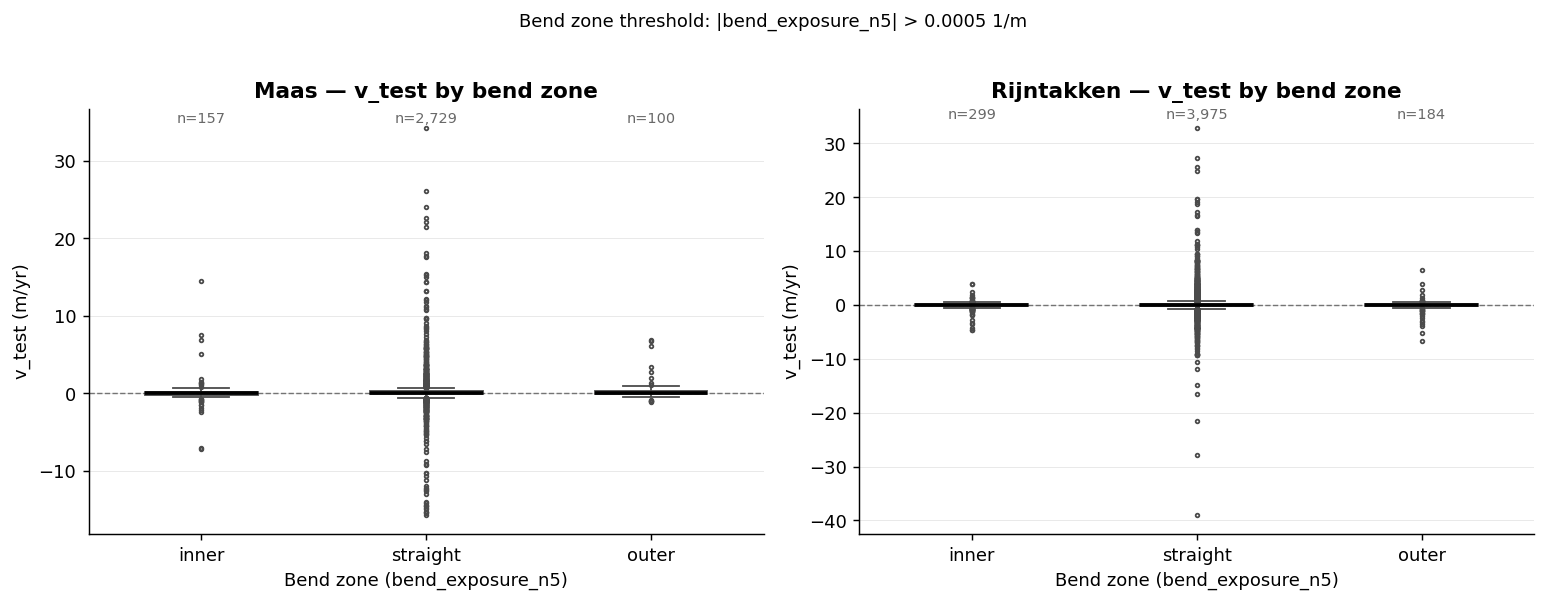


Kruskal-Wallis test (inner vs straight vs outer):
  Maas: H=1.55, p=4.617e-01
  Rijntakken: H=14.45, p=7.282e-04


In [117]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Bend zone boxplot (inner / straight / outer) × river system
# ══════════════════════════════════════════════════════════════════════════════

THRESH = 0.0005   # 1/m — boundary between straight and curved

features["bend_zone"] = pd.cut(
    features["bend_exposure_n5"],
    bins=[-np.inf, -THRESH, THRESH, np.inf],
    labels=["inner", "straight", "outer"]
)

# Count per zone per system
zone_counts = (
    features.assign(system=np.where(maas_mask, "Maas", "Rijntakken"))
    .groupby(["system", "bend_zone"], observed=True)
    .size().unstack(fill_value=0)
)
print("Scope regions per bend zone:")
display(zone_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
palette = {"inner": "#4575b4", "straight": "#ffffbf", "outer": "#d73027"}

for ax, (sys_name, mask) in zip(axes, systems.items()):
    sub = features.loc[mask].dropna(subset=["bend_zone", "v_test"])
    order = ["inner", "straight", "outer"]
    import seaborn as sns
    sns.boxplot(
        data=sub, x="bend_zone", y="v_test", order=order,
        palette=palette, width=0.5, fliersize=2,
        medianprops=dict(color="black", lw=2), ax=ax,
    )
    # Annotate n per group
    for i, zone in enumerate(order):
        n = (sub["bend_zone"] == zone).sum()
        med = sub.loc[sub["bend_zone"] == zone, "v_test"].median()
        ax.text(i, ax.get_ylim()[1] * 0.95, f"n={n:,}", ha="center",
                fontsize=8, color="dimgray")
    ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(f"{sys_name} — v_test by bend zone", fontweight="bold")
    ax.set_xlabel("Bend zone (bend_exposure_n5)")
    ax.set_ylabel("v_test (m/yr)")
    ax.grid(axis="y", alpha=0.3, lw=0.5)

plt.suptitle(f"Bend zone threshold: |bend_exposure_n5| > {THRESH} 1/m",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# Kruskal-Wallis test per system (non-parametric ANOVA — appropriate for skewed v_test)
print("\nKruskal-Wallis test (inner vs straight vs outer):")
for sys_name, mask in systems.items():
    sub    = features.loc[mask].dropna(subset=["bend_zone", "v_test"])
    groups = [sub.loc[sub["bend_zone"] == z, "v_test"].values for z in ["inner", "straight", "outer"]]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) >= 2:
        stat, p = stats.kruskal(*groups)
        print(f"  {sys_name}: H={stat:.2f}, p={p:.3e}")


## 10 — Correlation matrix

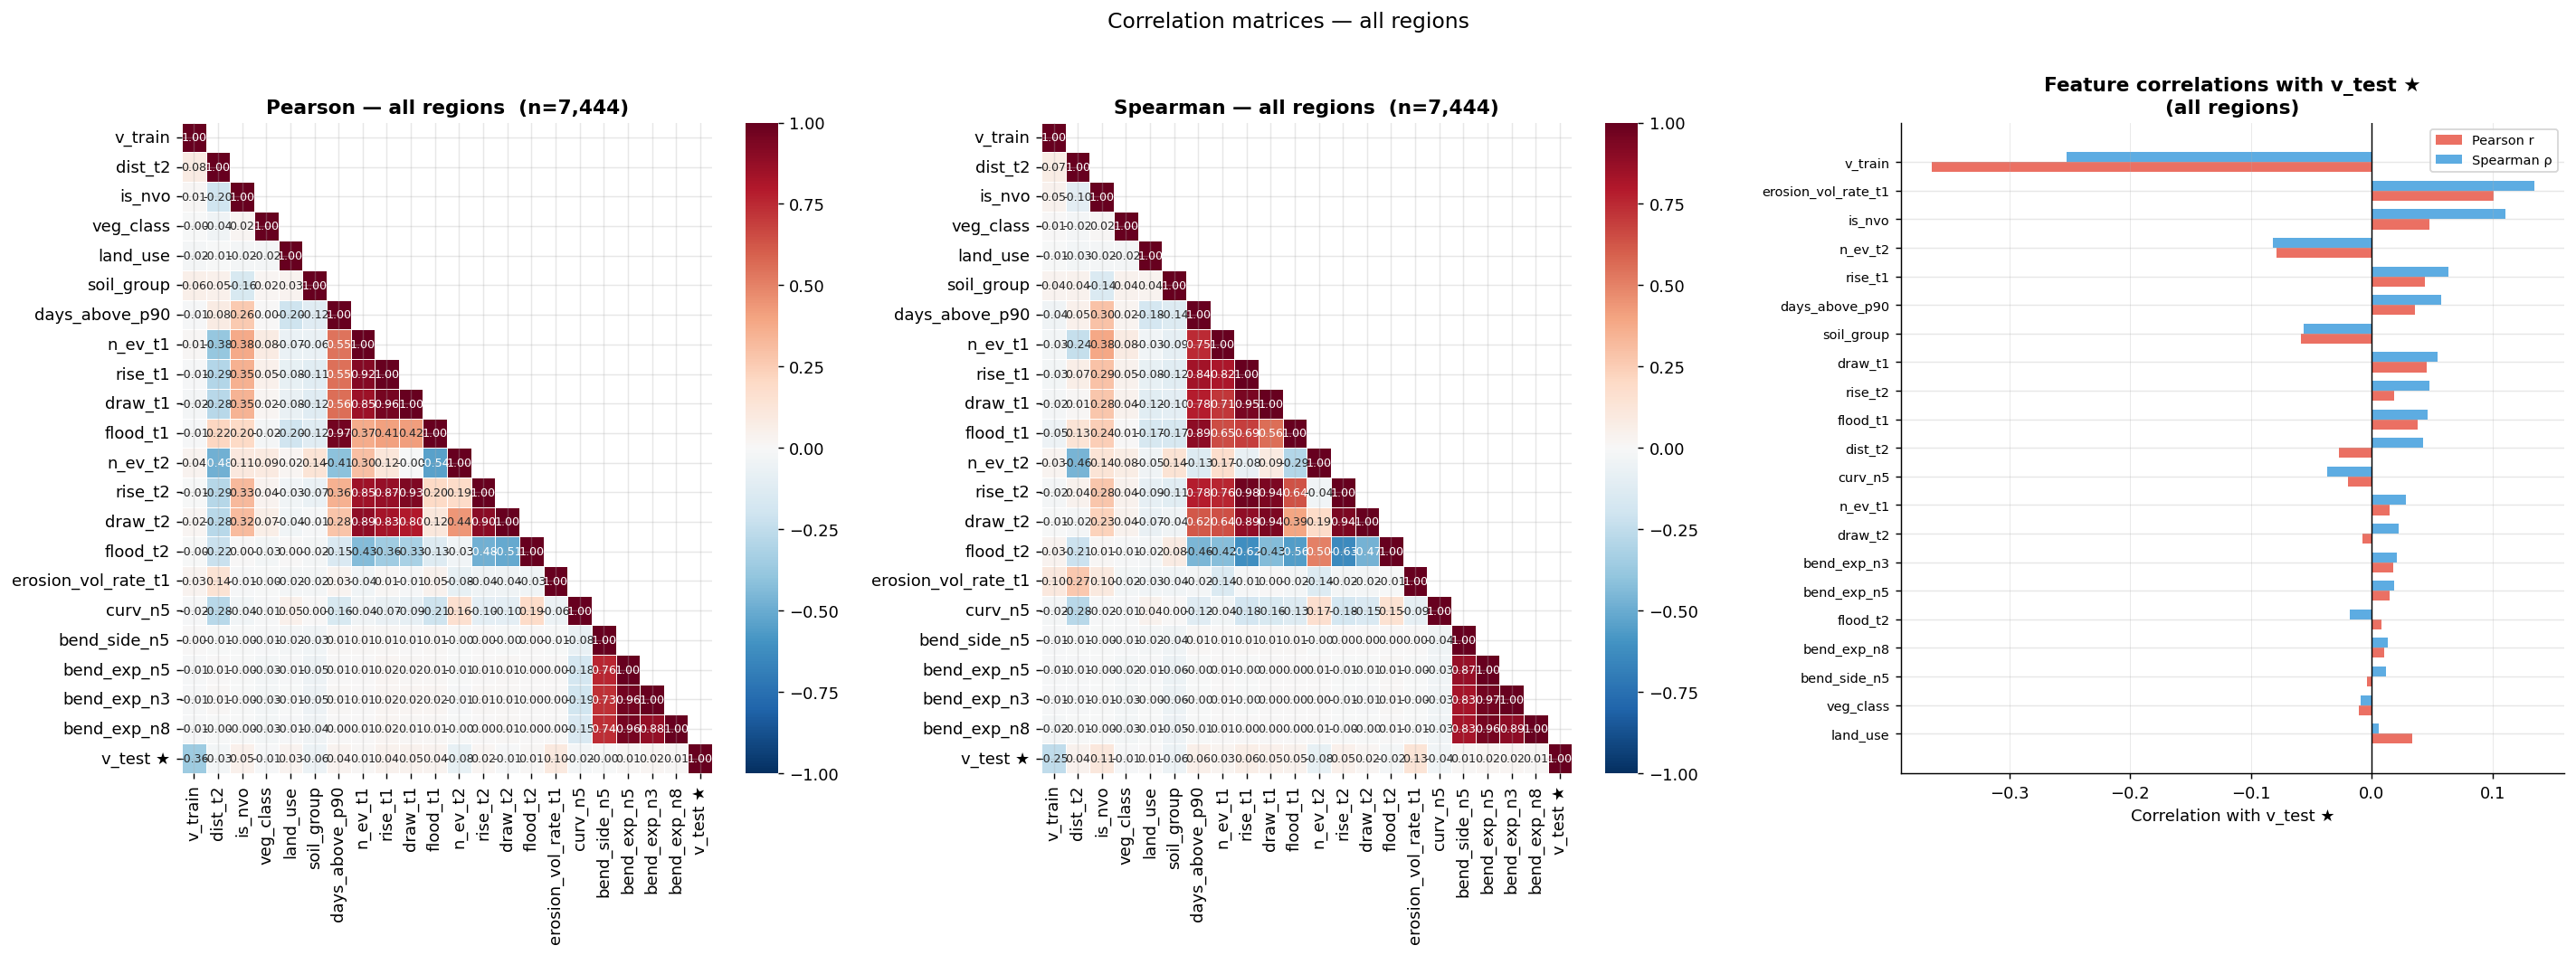


════════════════════════════════════════════════════════════
All regions — Pearson
════════════════════════════════════════════════════════════
Correlations with v_test (sorted by |r|):
v_train               -0.3644
erosion_vol_rate_t1    0.1006
n_ev_t2               -0.0792
soil_group            -0.0584
is_nvo                 0.0480
draw_t1                0.0456
rise_t1                0.0437
flood_t1               0.0382
days_above_p90         0.0358
land_use               0.0335
dist_t2               -0.0270
curv_n5               -0.0199
rise_t2                0.0184
bend_exp_n3            0.0175
bend_exp_n5            0.0149
n_ev_t1                0.0144
veg_class             -0.0112
bend_exp_n8            0.0101
draw_t2               -0.0081
flood_t2               0.0078
bend_side_n5          -0.0038

════════════════════════════════════════════════════════════
All regions — Spearman
════════════════════════════════════════════════════════════
Correlations with v_test (sorted by |

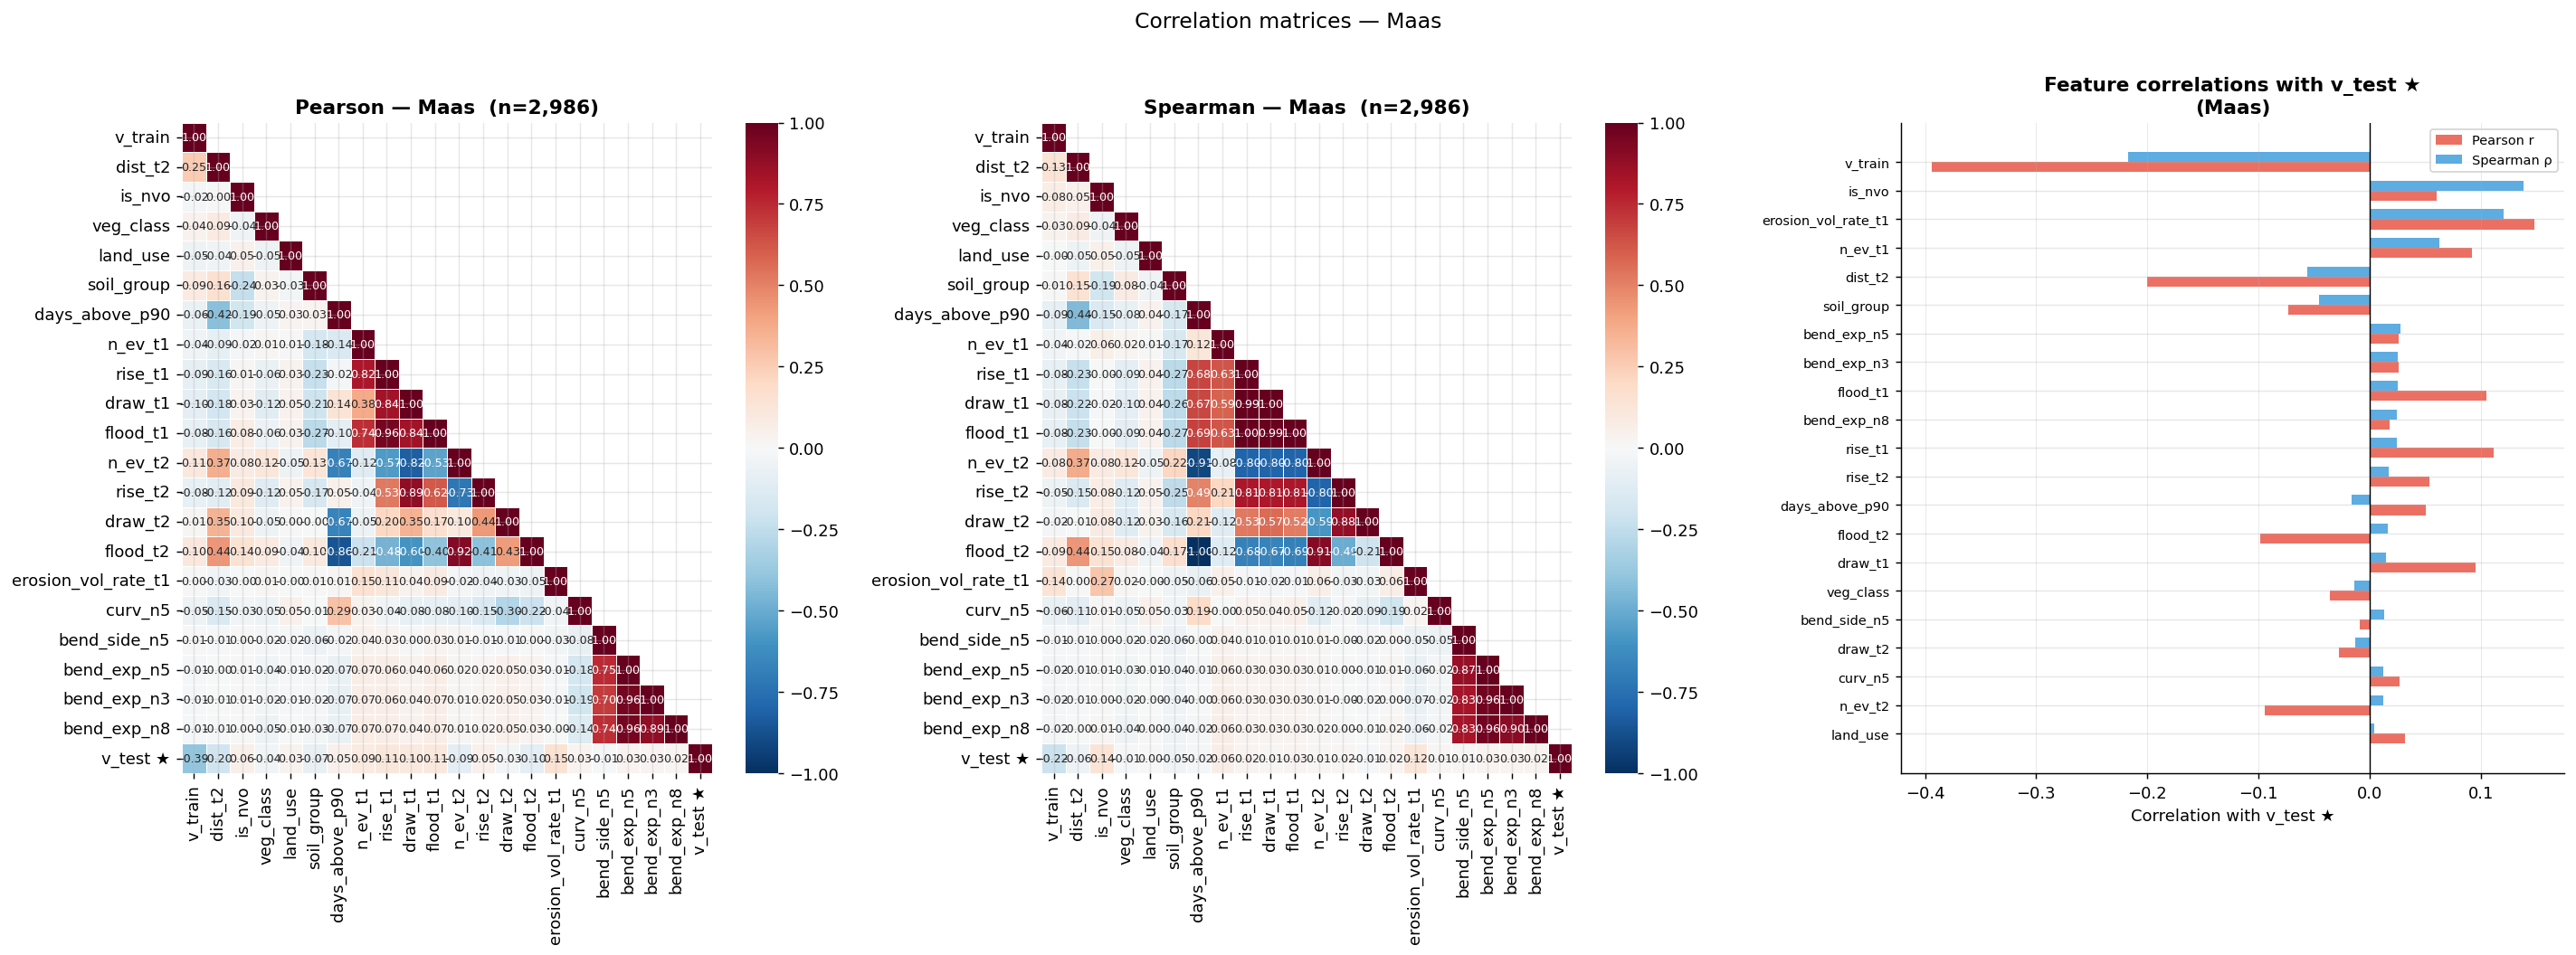


════════════════════════════════════════════════════════════
Maas — Pearson
════════════════════════════════════════════════════════════
Correlations with v_test (sorted by |r|):
v_train               -0.3942
dist_t2               -0.2000
erosion_vol_rate_t1    0.1481
rise_t1                0.1115
flood_t1               0.1056
flood_t2              -0.0984
draw_t1                0.0952
n_ev_t2               -0.0940
n_ev_t1                0.0921
soil_group            -0.0730
is_nvo                 0.0608
rise_t2                0.0542
days_above_p90         0.0510
veg_class             -0.0357
land_use               0.0319
draw_t2               -0.0277
curv_n5                0.0269
bend_exp_n5            0.0260
bend_exp_n3            0.0260
bend_exp_n8            0.0181
bend_side_n5          -0.0086

════════════════════════════════════════════════════════════
Maas — Spearman
════════════════════════════════════════════════════════════
Correlations with v_test (sorted by |r|):
v_train  

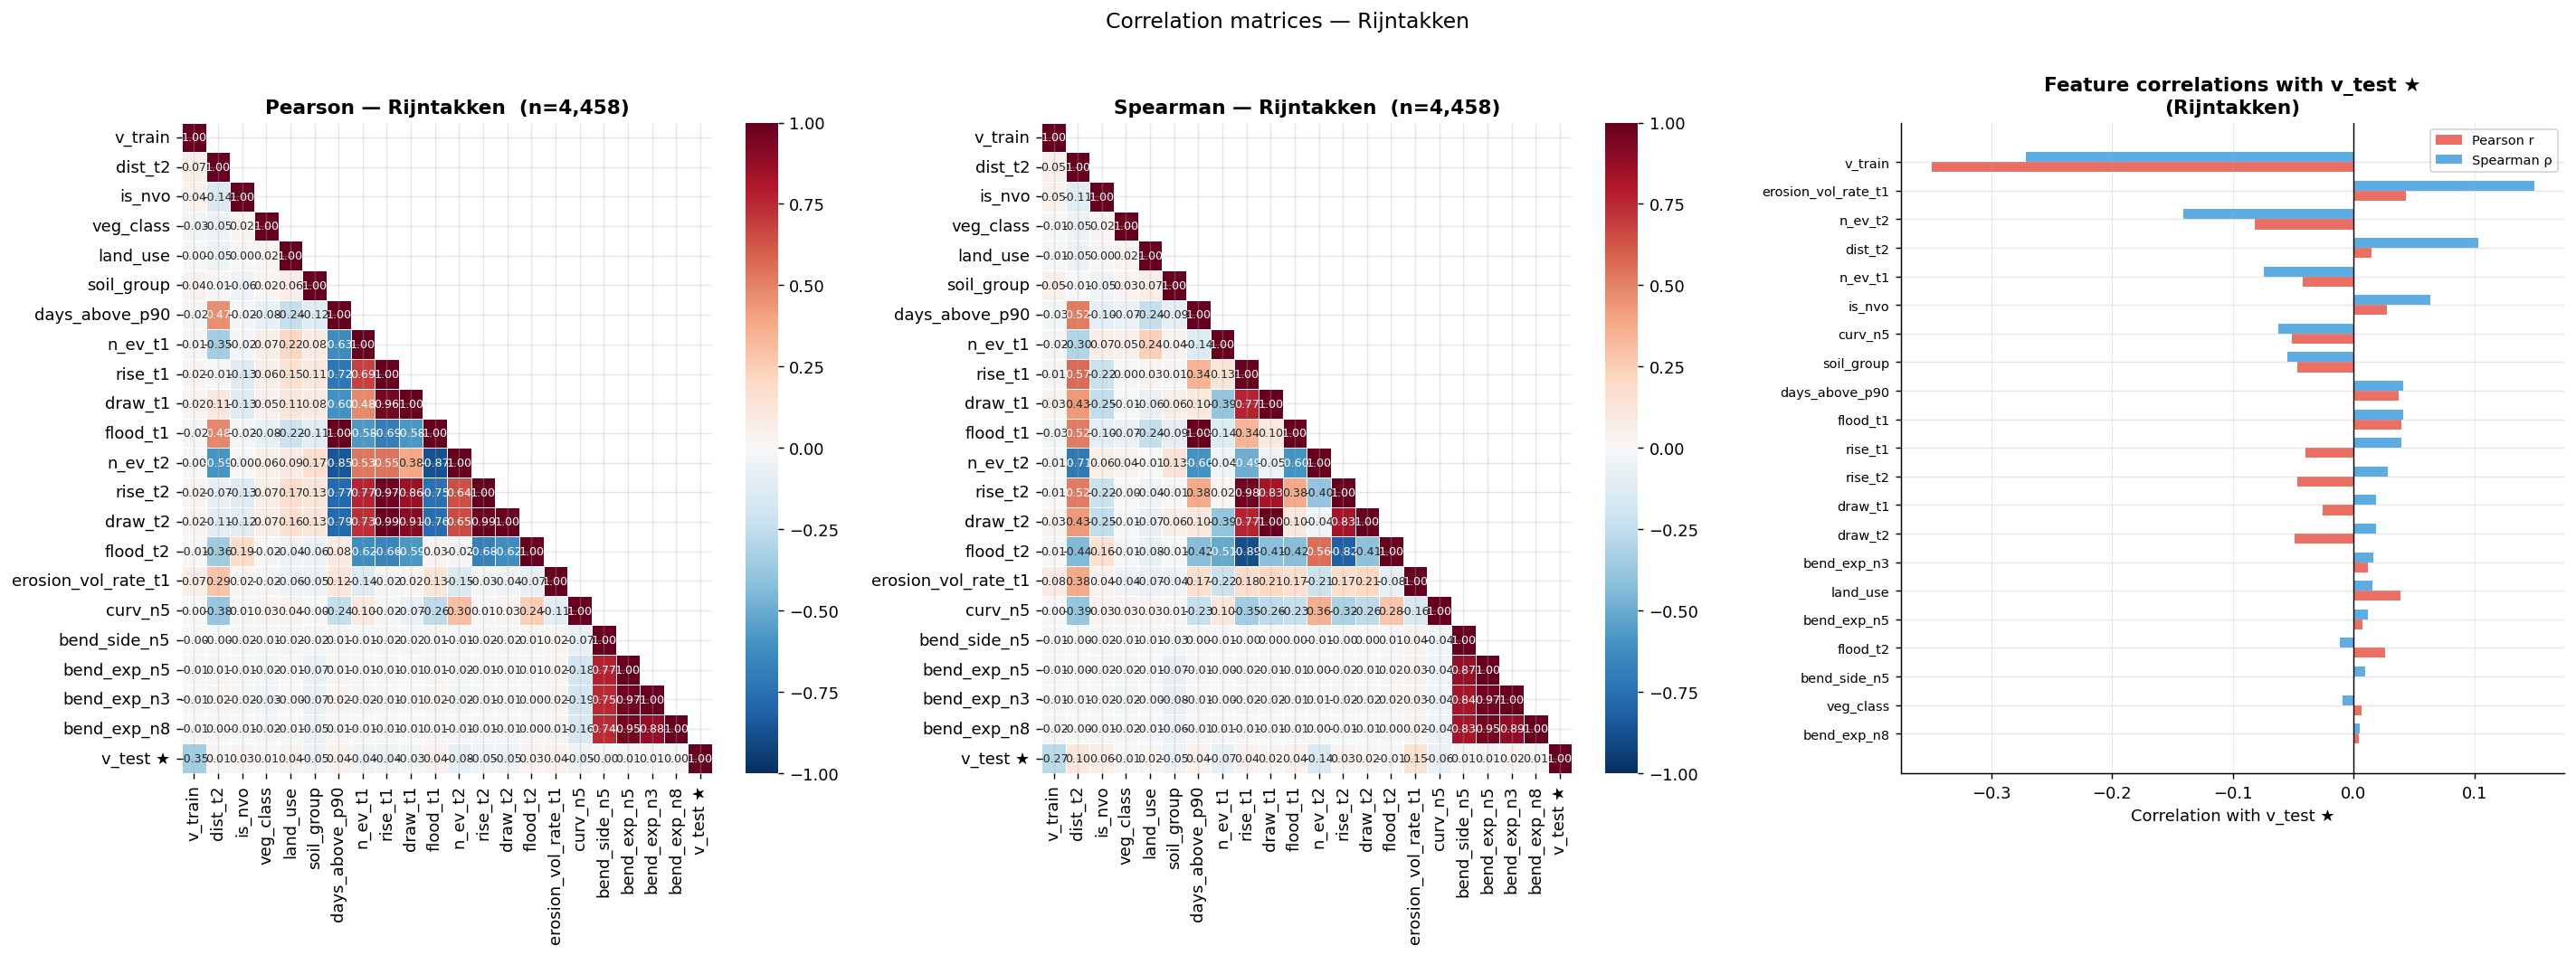


════════════════════════════════════════════════════════════
Rijntakken — Pearson
════════════════════════════════════════════════════════════
Correlations with v_test (sorted by |r|):
v_train               -0.3495
n_ev_t2               -0.0821
curv_n5               -0.0513
draw_t2               -0.0491
rise_t2               -0.0466
soil_group            -0.0465
erosion_vol_rate_t1    0.0431
n_ev_t1               -0.0421
rise_t1               -0.0397
flood_t1               0.0394
land_use               0.0386
days_above_p90         0.0375
is_nvo                 0.0272
flood_t2               0.0258
draw_t1               -0.0256
dist_t2                0.0148
bend_exp_n3            0.0116
bend_exp_n5            0.0072
veg_class              0.0065
bend_exp_n8            0.0046
bend_side_n5          -0.0005

════════════════════════════════════════════════════════════
Rijntakken — Spearman
════════════════════════════════════════════════════════════
Correlations with v_test (sorted by |r|

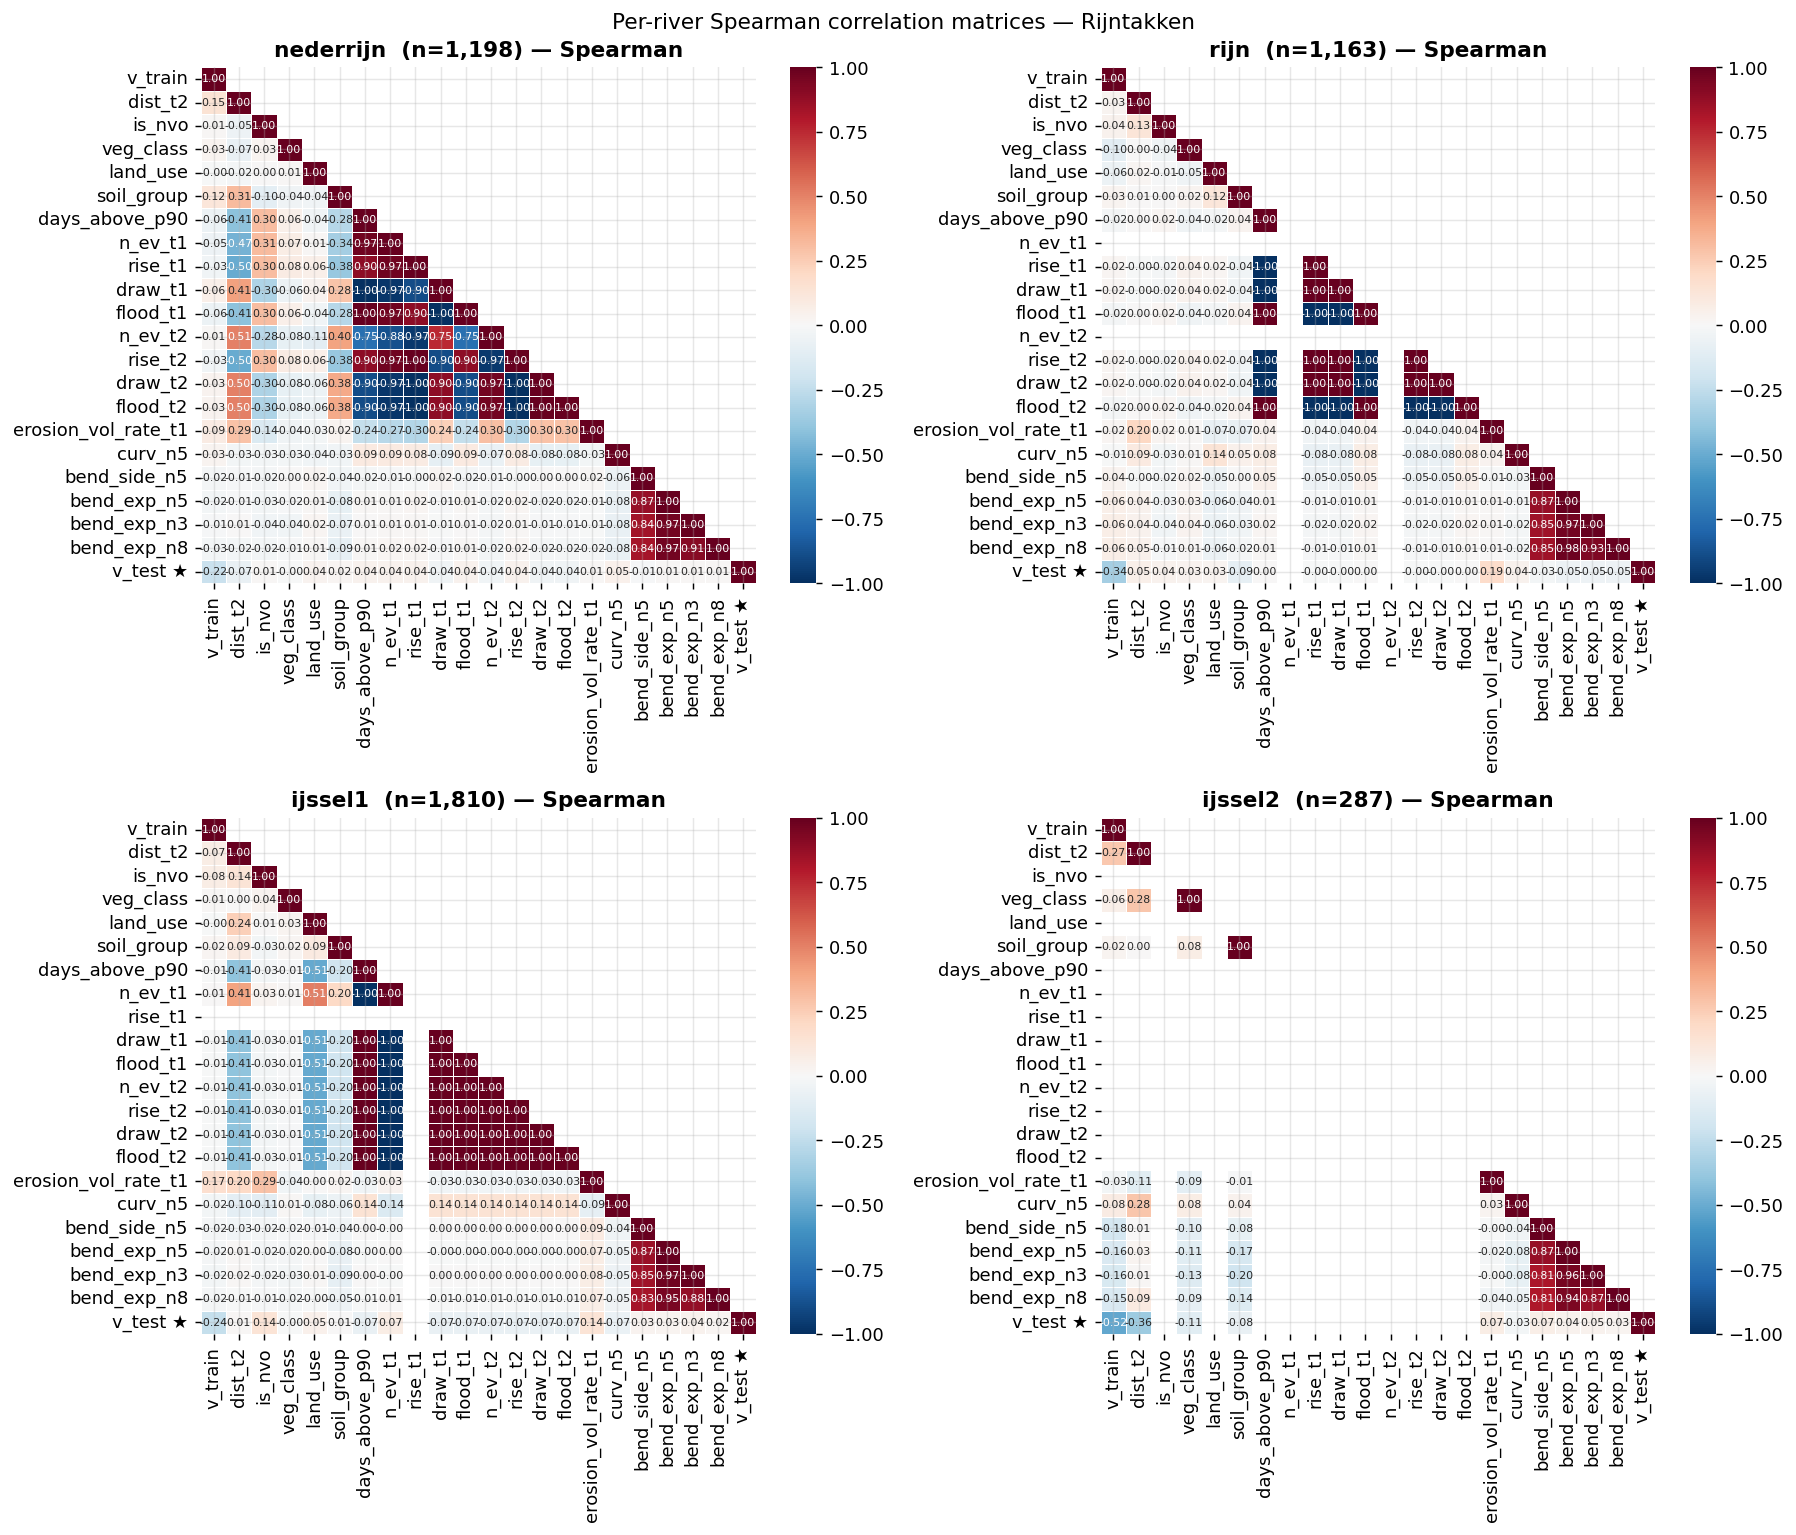


════════════════════════════════════════════════════════════
nederrijn — Spearman
════════════════════════════════════════════════════════════
Correlations with v_test (sorted by |r|):
v_train               -0.2249
dist_t2               -0.0732
curv_n5                0.0484
n_ev_t1                0.0441
days_above_p90         0.0431
draw_t1               -0.0431
flood_t1               0.0431
rise_t1                0.0428
rise_t2                0.0428
draw_t2               -0.0428
flood_t2              -0.0428
n_ev_t2               -0.0385
land_use               0.0372
soil_group             0.0233
bend_side_n5          -0.0126
bend_exp_n3            0.0125
is_nvo                 0.0121
bend_exp_n5            0.0111
erosion_vol_rate_t1    0.0108
bend_exp_n8            0.0098
veg_class             -0.0002

════════════════════════════════════════════════════════════
rijn — Spearman
════════════════════════════════════════════════════════════
Correlations with v_test (sorted by |r|):
v_t

In [127]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Full correlation matrices (Pearson + Spearman) with ranked v_test bar
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import LabelEncoder

BASE_COLS = ["v_train", "dist_t2", "is_nvo", "vegetation_class", "land_use",
             "soil_group", "days_above_p90"]


VOL_COLS  = ["erosion_vol_train_rate"]  # only erosion_vol_rate_t1 (train) in correlation matrix
GEOM_COLS = [
    "curvature_n5", "bend_side_n5", "bend_exposure_n5",   # primary scale
    "bend_exposure_n3", "bend_exposure_n8",                # scale comparison
]
HW_COLS = [
    "n_events_t1", "max_rise_rate_t1", "drawdown_index_t1", "flood_days_t1",
    "n_events_t2", "max_rise_rate_t2", "drawdown_index_t2", "flood_days_t2",
]

corr_cols = (
    BASE_COLS
    + [c for c in HW_COLS  if c in features.columns]
    + [c for c in VOL_COLS if c in features.columns]
    + [c for c in GEOM_COLS if c in features.columns]
    + ["v_test"]
)

RENAME = {
    "v_train":                "v_train",
    "dist_t2":                "dist_t2",
    "is_nvo":                 "is_nvo",
    "vegetation_class":       "veg_class",
    "land_use":               "land_use",
    "soil_group":             "soil_group",
    "n_events_t1":            "n_ev_t1",
    "max_rise_rate_t1":       "rise_t1",
    "drawdown_index_t1":      "draw_t1",
    "flood_days_t1":          "flood_t1",
    "n_events_t2":            "n_ev_t2",
    "max_rise_rate_t2":       "rise_t2",
    "drawdown_index_t2":      "draw_t2",
    "flood_days_t2":          "flood_t2",
    "erosion_vol_train_rate": "erosion_vol_rate_t1",
    "erosion_vol_test_rate":  "erosion_vol_rate_t2",
    "curvature_n5":           "curv_n5",
    "bend_side_n5":           "bend_side_n5",
    "bend_exposure_n5":       "bend_exp_n5",
    "bend_exposure_n3":       "bend_exp_n3",
    "bend_exposure_n8":       "bend_exp_n8",
    "v_test":                 "v_test ★",
}


def make_corr_df(df: pd.DataFrame) -> pd.DataFrame:
    """Encode categoricals and return renamed correlation-ready DataFrame."""
    out = df[[c for c in corr_cols if c in df.columns]].copy()
    out["is_nvo"] = out["is_nvo"].astype(float)
    for col in ["vegetation_class", "land_use", "soil_group"]:
        if col in out.columns:
            out[col] = LabelEncoder().fit_transform(out[col].fillna("__missing__"))
    return out.rename(columns={k: v for k, v in RENAME.items() if k in out.columns})


def plot_heatmap(ax, corr, title, annot_size=7):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.4,
                annot_kws={"size": annot_size})
    ax.set_title(title, fontweight="bold")


def plot_vtest_bar(ax, corr_pearson, corr_spearman, title):
    """Ranked horizontal bar chart: Pearson r and Spearman ρ with v_test ★."""
    target = "v_test ★"
    p = corr_pearson[target].drop(target, errors="ignore").rename("pearson")
    s = corr_spearman[target].drop(target, errors="ignore").rename("spearman")
    combined = pd.concat([p, s], axis=1).dropna()
    combined = combined.reindex(combined["spearman"].abs().sort_values().index)

    y      = np.arange(len(combined))
    height = 0.35
    ax.barh(y - height / 2, combined["pearson"],  height, label="Pearson r",   color="#e74c3c", alpha=0.8)
    ax.barh(y + height / 2, combined["spearman"], height, label="Spearman ρ",  color="#3498db", alpha=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(combined.index, fontsize=8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Correlation with v_test ★")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="x", alpha=0.3, lw=0.5)


def print_corr(corr, label):
    print(f"\n{'═'*60}\n{label}\n{'═'*60}")
    if "v_test ★" in corr.columns:
        print("Correlations with v_test (sorted by |r|):")
        print(corr["v_test ★"].drop("v_test ★", errors="ignore")
              .sort_values(key=abs, ascending=False).round(4).to_string())


# ── All regions ──────────────────────────────────────────────────────────────
df_all        = make_corr_df(features)
corr_p_all    = df_all.corr(method="pearson")
corr_s_all    = df_all.corr(method="spearman")

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
plot_heatmap(axes[0], corr_p_all,  f"Pearson — all regions  (n={len(df_all):,})")
plot_heatmap(axes[1], corr_s_all,  f"Spearman — all regions  (n={len(df_all):,})")
plot_vtest_bar(axes[2], corr_p_all, corr_s_all, "Feature correlations with v_test ★\n(all regions)")
plt.suptitle("Correlation matrices — all regions", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print_corr(corr_p_all, "All regions — Pearson")
print_corr(corr_s_all, "All regions — Spearman")

# ── Maas vs Rijntakken ───────────────────────────────────────────────────────
for sys_name, mask in systems.items():
    df_sys     = make_corr_df(features.loc[mask])
    corr_p_sys = df_sys.corr(method="pearson")
    corr_s_sys = df_sys.corr(method="spearman")
    n_sys      = mask.sum()

    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    plot_heatmap(axes[0], corr_p_sys, f"Pearson — {sys_name}  (n={n_sys:,})")
    plot_heatmap(axes[1], corr_s_sys, f"Spearman — {sys_name}  (n={n_sys:,})")
    plot_vtest_bar(axes[2], corr_p_sys, corr_s_sys,
                   f"Feature correlations with v_test ★\n({sys_name})")
    plt.suptitle(f"Correlation matrices — {sys_name}", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()
    print_corr(corr_p_sys, f"{sys_name} — Pearson")
    print_corr(corr_s_sys, f"{sys_name} — Spearman")

# ── Per river cluster ────────────────────────────────────────────────────────
CLUSTERS = ["nederrijn", "rijn", "ijssel1", "ijssel2"]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, river in zip(axes.flatten(), CLUSTERS):
    sub = make_corr_df(features.loc[features["river"] == river])
    plot_heatmap(ax, sub.corr(method="spearman"),
                 f"{river}  (n={len(sub):,}) — Spearman", annot_size=6)
plt.suptitle("Per-river Spearman correlation matrices — Rijntakken", fontsize=12)
plt.tight_layout(); plt.show()

for river in CLUSTERS:
    sub = make_corr_df(features.loc[features["river"] == river])
    print_corr(sub.corr(method="spearman"), f"{river} — Spearman")


In [ ]:
# Export scope regions with station attribution for QGIS
# Joins station, spi, dist_t2, v_train onto scope geometries; adds station points as separate layer

export_cols = ["station", "river", "spi", "dist_t2", "v_train"]
export_cols = [c for c in export_cols if c in features.columns]
gdf = scope.join(features[export_cols])
gdf = gdf.reset_index()  # location_id as column for GeoPackage
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=scope.crs)

# Station locations (discharge stations) as point layer
stations_gdf = gpd.read_file(str(STATIONS_GPKG), layer="discharge_stations")
stations_gdf = stations_gdf.to_crs(scope.crs)
# Rename CODE to station for consistency
if "CODE" in stations_gdf.columns:
    stations_gdf = stations_gdf.rename(columns={"CODE": "station"})

OUT_DIR = PATHS.DATA_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_GPKG = OUT_DIR / "station_attribution.gpkg"

gdf.to_file(str(OUT_GPKG), layer="scope_regions", driver="GPKG")
stations_gdf.to_file(str(OUT_GPKG), layer="discharge_stations", driver="GPKG")
print(f"Exported to {OUT_GPKG}")
print(f"  Layer 'scope_regions': {len(gdf):,} polygons with {list(gdf.columns)}")
print(f"  Layer 'discharge_stations': {len(stations_gdf):,} points")

## 11 — Takeaways and next steps

*(Filled in from v2 EDA run — 7,444 regions, OK-only quality filter.)*

### Feature signal summary

| Feature | Coverage | Signal strength | Relationship | Notes |
|---|---|---|---|---|
| `v_train` | 100% | ★★★★ | Negative linear (r≈−0.36, mean-reversion) | Best single predictor; R²≈0.13 |
| `dist_t2` | 100% | ★★ | Weak monotone (r≈−0.03) | Per-cluster varies; confounded by river/NVO |
| `is_nvo` | 100% | ★★★ | Categorical shift (r≈0.05) | NVO banks erode faster |
| `river` | 100% | ★★★ | Categorical (ANOVA p≈10⁻⁷¹) | Proxy for discharge + morphology |
| `vegetation_class` | 73% | ★★ | Weak (r≈−0.01) | Soft veg → more erosion? Low ordinal signal |
| `land_use` | 39% | ★ | Very weak (r≈0.03) | Low coverage limits usefulness |
| `soil_group` | 89% | ★★ | Weak (r≈−0.06) | Clay > sandy > peat resistance? |
| `peak_P99 discharge` | 100% | ★ | Very weak (r≈−0.03) | Largely collinear with river |
| `erosion_vol_test_rate` | 100% | ★ | Weak (Spearman ρ≈0.08, p≈9e−12) | Volume-based; not used as feature yet |

### Model recommendation

Based on v2 EDA:
- Start with **Ridge regression** using: `v_train`, `dist_t2`, `is_nvo`, `river` (dummy), `vegetation_class` (dummy), `soil_group` (dummy)
- Compare with **LightGBM** which handles non-linearity and missing values natively
- If `vegetation_class × is_nvo` interaction is strong → tree model will be better

### Next steps
1. Produce `region_features_v2.parquet` enriching `region_split_v2` with all features above
2. Train Ridge and LightGBM on v2, compare RMSE on test split
3. Use SHAP values (LightGBM) to interpret which features matter most
4. Optional: add `erosion_vol_test_rate` as feature; run oracle discharge test (test-period discharge)

---

### Layman explanation: how each feature is calculated

| Feature | Simple explanation |
|---|---|
| **`v_train`** | Bank erosion rate over the *training* period. Measured how many metres per year the river bank moved inward (erosion) or outward (accretion). Formula: `(distance at t2 − distance at t1) / (years between t1 and t2)`. |
| **`v_test`** | Same as `v_train` but for the *test* period. This is your target: what you want to predict. |
| **`dist_t2`** | How far the river bank is from the river centreline at the middle time point (t2). Measured in metres. Banks further from the centreline are often more stable; closer banks may be more exposed to flow. |
| **`is_nvo`** | Yes/no: is this a nature-friendly bank (NVO)? NVO banks have gentle slopes and soft vegetation → tend to erode faster than conventional banks. |
| **`river`** | Which river segment the bank belongs to (e.g. Maas, Rijn, IJssel). Parsed from the segment ID. Different rivers have different flow and bank protection. |
| **`vegetation_class`** | Dominant vegetation type from the Vegetatielegger (vegetation map). For each bank segment, we take the vegetation class that covers the largest area. Examples: reed, grass, forest, etc. |
| **`land_use`** | Dominant land use from BRP Gewas (agricultural register). For each bank segment, we take the land use category that covers the largest area. Examples: grassland, maize, forest. |
| **`soil_group`** | Soil type from the BRO Bodemkaart. For each bank polygon, we find which soil types intersect it and take the dominant one. Grouped into broad classes (e.g. river clay, sandy, peat). |
| **`peak_p99`** | Peak discharge at the nearest gauge. For each year in the training window, we take the 99th percentile of daily discharge (m³/s). Then we average those yearly peaks. Higher peak flow → more erosive power. |
| **`days_above_p90`** | Number of days per year that discharge exceeded the 90th percentile. Averaged over the training window. More days of high flow → more erosion opportunity. |
| **`erosion_vol_train_rate`** | Erosion volume (m³) from erosion polygons over the training period, divided by the number of years. Gives m³ per year. |
| **`erosion_vol_test_rate`** | Same as above but for the test period. Currently not used as a model feature. |


---
## Build — `region_features.parquet`

This section produces the enriched feature table used for model training.
All the joins done in the EDA above are repeated here in one clean pipeline.

**Output columns:**

| Column | Type | Source |
|---|---|---|
| `v_train`, `v_test` | numeric | `region_split.parquet` |
| `dist_t1/2/3` | numeric | `region_split.parquet` |
| `train_span_yr`, `test_span_yr` | numeric | `region_split.parquet` |
| `is_nvo` | bool | `region_split.parquet` |
| `river` | string + `_enc` int | parsed from `location_id` |
| `vegetation_class` | string + `_enc` int | `vegetatielegger.gpkg` (pre-joined) |
| `land_use` | string + `_enc` int | `land_use.gpkg` (pre-joined) |
| `soil_group` | string + `_enc` int | `BRO_DownloadBodemkaart.gpkg` (spatial join) |
| `peak_p99`, `days_above_p90` | numeric | `timeseries/discharge/` (nearest station) |
| `split`, `cluster` | metadata | `region_split.parquet` |

Categorical `_enc` columns use the ordinal mappings in `src.constants.KNOWN_CATEGORIES`.
Unknown values are encoded as `-1` (following `CONST.DEFAULT_UNKNOWN_CATEGORY_LABEL`).


In [131]:
import src.constants as CONST
OUT_PATH = PATHS.DATA_DIR / "02_processed/erosion/region_features.parquet"

# ── Helper: ordinal-encode a column using KNOWN_CATEGORIES ───────────────────
def encode_col(series: pd.Series, category_key: str) -> pd.Series:
    mapping = {v: i for i, v in enumerate(CONST.KNOWN_CATEGORIES[category_key])}
    return series.map(lambda x: mapping.get(x, CONST.DEFAULT_UNKNOWN_CATEGORY_LABEL))

# ── 1. Base table ─────────────────────────────────────────────────────────────
print("Loading region_split...")
feat = pd.read_parquet(SPLIT_PATH)
feat["river"] = feat.index.to_series().str.extract(r"^([a-z]+\d*)_")[0]
if "erosion_vol_train_rate" in feat.columns:
    feat["erosion_vol_rate_t1"] = feat["erosion_vol_train_rate"]
print(f"  {len(feat):,} rows")

# ── 2. Vegetation class ───────────────────────────────────────────────────────
print("Loading vegetation class...")
veg = gpd.read_file(str(VEG_GPKG), layer="rws_vegetatielegger:vegetatieklassen")
veg["area"] = veg.geometry.area
dom_veg = (veg.sort_values("area", ascending=False)
           .groupby("scope_region_id")["vlklasse"]
           .first()
           .rename("vegetation_class"))
feat["vegetation_class"] = feat.index.map(dom_veg)
rare = {"90/10", "70/30", "50/50"}
feat["vegetation_class"] = feat["vegetation_class"].apply(
    lambda x: "Other" if x in rare else x
)
print(f"  Assigned: {feat['vegetation_class'].notna().sum():,}  |  "
      f"Missing: {feat['vegetation_class'].isna().sum():,}")

# ── 3. Land use ───────────────────────────────────────────────────────────────
print("Loading land use...")
lu = gpd.read_file(str(LU_GPKG), layer="BrpGewas")
lu["area"] = lu.geometry.area
dom_lu = (lu.sort_values("area", ascending=False)
          .groupby("scope_region_id")["category"]
          .first()
          .rename("land_use"))
feat["land_use"] = feat.index.map(dom_lu)
print(f"  Assigned: {feat['land_use'].notna().sum():,}  |  "
      f"Missing: {feat['land_use'].isna().sum():,}")

# ── 4. Soil type ──────────────────────────────────────────────────────────────
print("Loading Bodemkaart (spatial join, ~30s)...")
scope_join = gpd.read_file(str(SCOPE_GPKG), layer="vlakken_scope")
scope_join = scope_join.rename(columns={"position_id":"location_id"}).set_index("location_id")[["geometry"]]
scope_join = scope_join[scope_join.index.isin(feat.index)]
soil_poly  = gpd.read_file(str(SOIL_GPKG), layer="soilarea")[["maparea_id","geometry"]]
soil_codes = gpd.read_file(str(SOIL_GPKG), layer="soilarea_soilunit")[["maparea_id","soilunit_code"]]
soil_poly  = soil_poly.merge(soil_codes, on="maparea_id", how="left")
joined_soil = gpd.overlay(scope_join.reset_index(),
                           soil_poly[["soilunit_code","geometry"]],
                           how="intersection", keep_geom_type=False)
joined_soil["area"] = joined_soil.geometry.area
dom_soil = (joined_soil.sort_values("area", ascending=False)
            .groupby("location_id")["soilunit_code"].first())

def soil_group_fn(code):
    if pd.isna(code): return np.nan
    c = str(code)
    if c[:2] in ("Rd","Rn","Ro"): return "River clay"
    elif c[0] == "Z":             return "Sandy"
    elif c[:2] in ("Mv","Mo","pM") or c[0] == "b": return "Soft (peat/podzol)"
    elif c[:2] == "Mn":           return "River sand-clay"
    else:                         return "Other"

feat["soil_group"] = feat.index.map(dom_soil).map(soil_group_fn)
print(f"  Assigned: {feat['soil_group'].notna().sum():,}  |  "
      f"Missing: {feat['soil_group'].isna().sum():,}")

# ── 5. Discharge ──────────────────────────────────────────────────────────────
print("Joining high-water window metrics from features...")
HW_WINDOW_COLS = [
    "n_events_t1", "max_rise_rate_t1", "drawdown_index_t1", "flood_days_t1",
    "n_events_t2", "max_rise_rate_t2", "drawdown_index_t2", "flood_days_t2",
]
hw_cols_present = [c for c in HW_WINDOW_COLS if c in features.columns]
feat[hw_cols_present] = features[hw_cols_present].reindex(feat.index)
n_ok = feat[hw_cols_present].notna().all(axis=1).sum()
print(f"  Assigned: {n_ok:,} / {len(feat):,} regions "
      f"({n_ok / len(feat) * 100:.1f}%)")

# ── 6. Curvature (bend_exposure_n5, bend_exposure_n8) ────────────────────────
print("Loading curvature features from region_features_v2...")
FEATURES_V2_PATH = PATHS.DATA_DIR / "02_processed/erosion/region_features_v2.parquet"
CURV_KEEP = ["bend_exposure_n5", "bend_exposure_n8"]

if FEATURES_V2_PATH.exists():
    feat_v2 = pd.read_parquet(FEATURES_V2_PATH, columns=CURV_KEEP)
    feat[CURV_KEEP] = feat_v2.reindex(feat.index)
    n_ok = feat[CURV_KEEP].notna().all(axis=1).sum()
    print(f"  Assigned: {n_ok:,} / {len(feat):,} regions "
          f"({n_ok / len(feat) * 100:.1f}%)")
else:
    print(f"  WARNING: region_features_v2 not found at {FEATURES_V2_PATH}")
    print(f"  bend_exposure columns will be NaN — run preprocessing first.")
    feat[CURV_KEEP] = np.nan

# ── 7. Ordinal-encode all categoricals ────────────────────────────────────────
feat["vegetation_class_enc"] = encode_col(feat["vegetation_class"],
                                           "rws_vegetatielegger:vegetatieklassen_majority_class_vlklasse")
feat["land_use_enc"]         = encode_col(feat["land_use"],
                                           "BrpGewas_majority_class_category")
feat["river_enc"]            = encode_col(feat["river"],        "river")
feat["soil_group_enc"]       = encode_col(feat["soil_group"],   "soil_group")

print("\nEncoding check (NaN → -1):")
for col in ["river_enc","vegetation_class_enc","land_use_enc","soil_group_enc"]:
    unk = (feat[col] == CONST.DEFAULT_UNKNOWN_CATEGORY_LABEL).sum()
    print(f"  {col}: {unk:,} unknown ({unk/len(feat):.1%})")

# ── 8. Save ───────────────────────────────────────────────────────────────────
cols_out = [
    "v_train", "v_test",
    "dist_t1", "dist_t2", "dist_t3",
    "train_span_yr", "test_span_yr",
    "is_nvo",
    "river", "river_enc",
    "vegetation_class", "vegetation_class_enc",
    "land_use", "land_use_enc",
    "erosion_vol_rate_t1",
    "soil_group", "soil_group_enc",
    "n_events_t1", "max_rise_rate_t1", "drawdown_index_t1", "flood_days_t1",
    "n_events_t2", "max_rise_rate_t2", "drawdown_index_t2", "flood_days_t2",
    "bend_exposure_n5", "bend_exposure_n8",
    "split", "cluster",
]
out = feat[[c for c in cols_out if c in feat.columns]]
out.to_parquet(OUT_PATH)
print(f"\nSaved {len(out):,} rows × {len(out.columns)} cols → {OUT_PATH.name}")
print("\nColumn summary:")
print(out.dtypes.to_string())

Loading region_split...
  7,444 rows
Loading vegetation class...
  Assigned: 5,420  |  Missing: 2,024
Loading land use...
  Assigned: 2,871  |  Missing: 4,573
Loading Bodemkaart (spatial join, ~30s)...
  Assigned: 6,639  |  Missing: 805
Joining high-water window metrics from features...
  Assigned: 7,444 / 7,444 regions (100.0%)
Loading curvature features from region_features_v2...
  Assigned: 7,444 / 7,444 regions (100.0%)

Encoding check (NaN → -1):
  river_enc: 0 unknown (0.0%)
  vegetation_class_enc: 2,121 unknown (28.5%)
  land_use_enc: 4,577 unknown (61.5%)
  soil_group_enc: 805 unknown (10.8%)

Saved 7,444 rows × 29 cols → region_features.parquet

Column summary:
v_train                 float64
v_test                  float64
dist_t1                 float64
dist_t2                 float64
dist_t3                 float64
train_span_yr             int64
test_span_yr              int64
is_nvo                     bool
river                    object
river_enc                 int64
v